# 1. Answer the questions:

## 1. Propose a new method to initialize cluster centroids for K-means. List the advantages and disadvantages of Forgy, Random Partition, and your own initializations.

- Для K-means существует несколько способов инициализации центроидов: random partition, forgy, k-means++.
Источник картинок: https://medium.com/analytics-vidhya/comparison-of-initialization-strategies-for-k-means-d5ddd8b0350e


### Forgy
Выбор случайных k точек данных как начальных центроидов. Соответственно, проинициализированные центроиды будут близки к модам исходных данных(будущих кластеров).

**Плюсы**: быстро, просто;

**Минусы**: результат зависит от начальной инициализации (лучше визуализировать, чтобы убедиться в хорошем стартовом состоянии и не было ситуации, когда два центроида проинициализированы в пределах одного кластера).



2, 3, 4, 5, 6, 9, 10 - плохие состояния, скорее всего, алгоритм застрянет в локальном минимуме и итоговое качество кластеризации будет плохое;
1, 7, 8 - хорошие стартовые состояния.

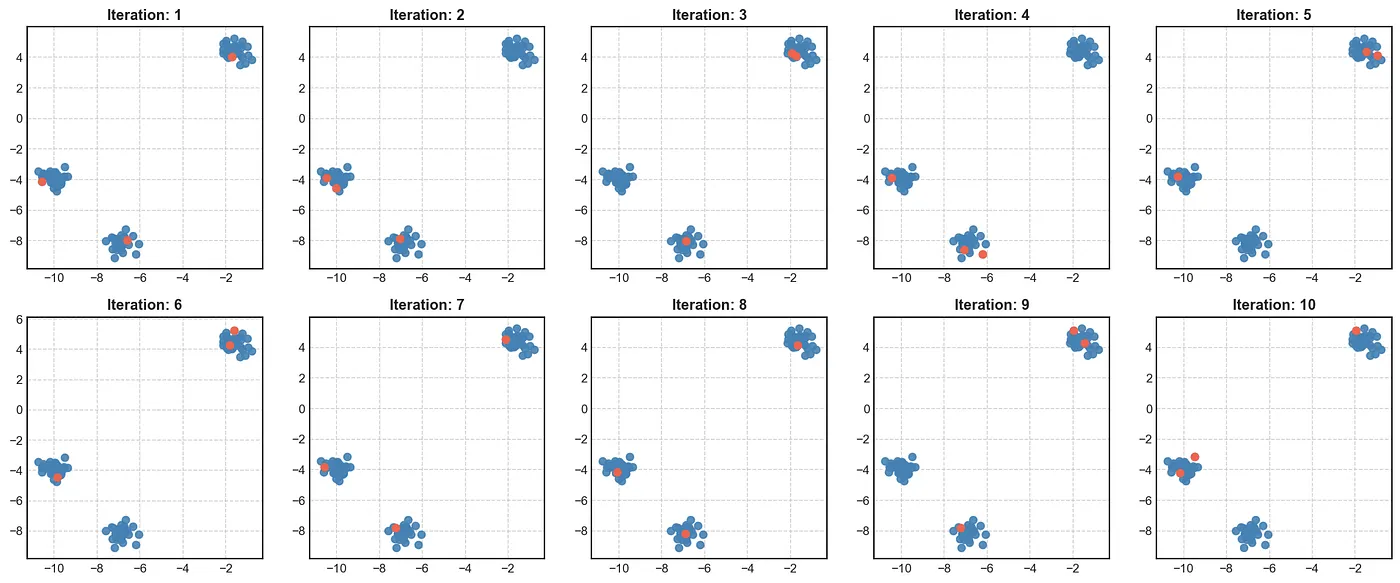

### Random Partition
Метод начинается с присвоения каждой точки данных рандомному кластеру, затем высчитывается среднее по каждому кластеру для инициализации соответствующего центроида. Проинициализированные центроиды будут близки к среднему исходных данных.

**Плюсы**: тоже быстро и просто;

**Минусы**: легко застрять в локальном минимуме; зависимость от начальной инициализации; есть статьи, доказывающие, что конкретно для модели k-means это неоптимальный способ инициализации (https://dl.acm.org/doi/10.1145/584792.584890).

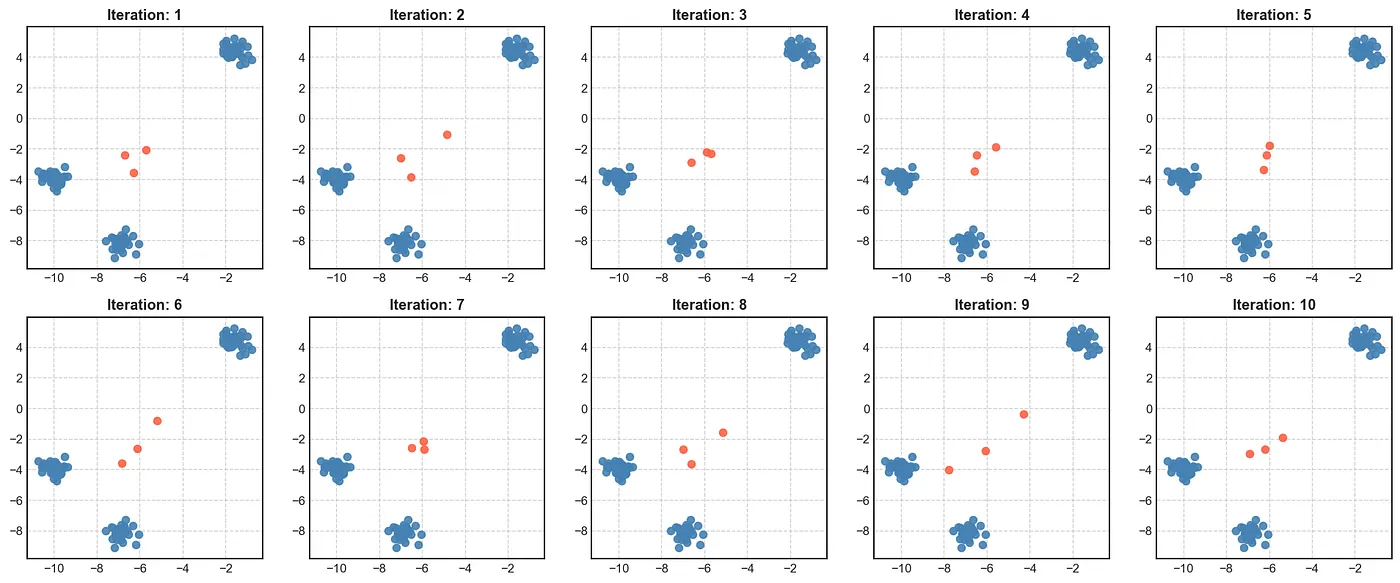

### k-means++
Как видно из названия, это специально разработанный для k-means улучшенный способ инициализации. Первый центроид выбирается рандомно; для выбора каждого следующего центроида рассчитываются расстояния и распределения между точками данных и выбирается самый дальний

**Плюсы**: улучшенная сходимость (быстрее), повышение качества кластеризации, воспроизводимость результатов;

**Минусы**: начальные вычислительные затраты на инициализацию центроидов.

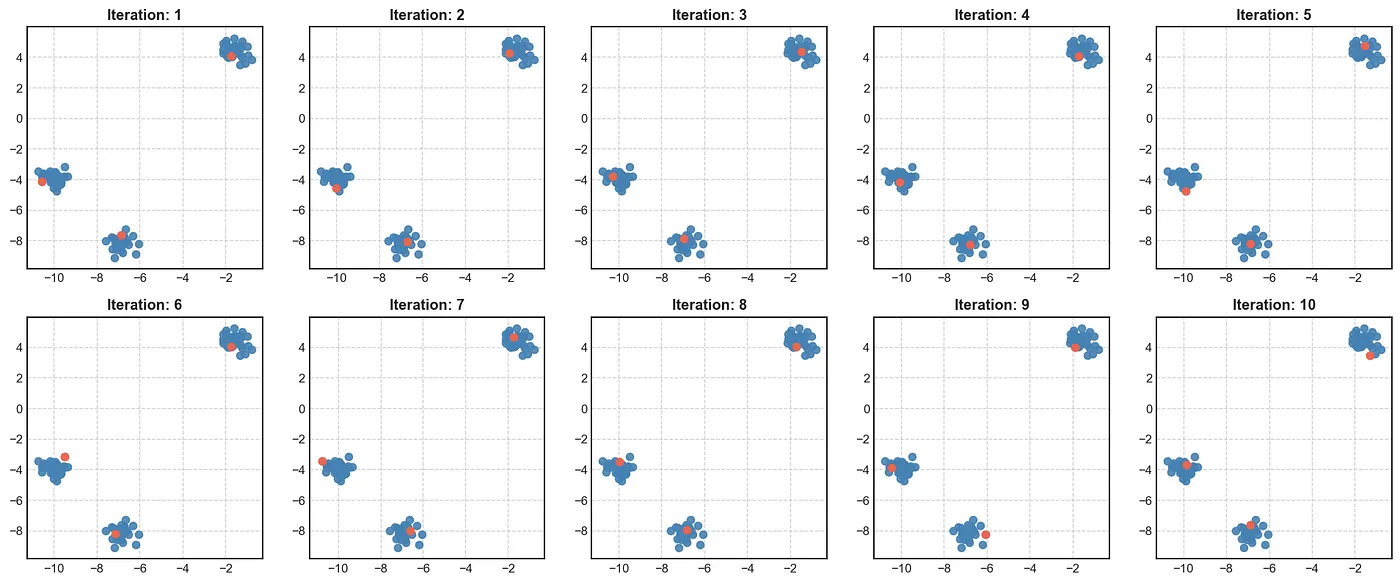

## 2. Describe how you can use clustering to speed up the KNN model. Hint: what is kd-tree?

### ANN - Approximate k-Nearest Neigbours
- набор алгоритмов, которые способны находить близкую точку данных к заданной, но необязательно ближайшую (как в стандартном kNN). Соответственно, если нужен идеальный мэтч - лучше использовать kNN, если точностью целесообразно пожертвовать ради скорости - то ANN.

- применяются для больших датасетов, разреженных данных (в сочетании с уменьшением размерности), в рекомендательных системах и векторном поиске (изображения, текст и тд).

### Разновидности ANN
очень много разных алгоритмов и библиотек:
- **KD-tree** - структура данных

- **LSH (Locality-Sensitive Hashing)** - метод предварительной фильтрации и индексации, использующий специализированную хэш-функцию, цель которой - максимизировать зависимость выхода от близости входа (то есть противоположно привычным хэш-функциям в словарях). Если точки похожи - максимизировать вероятность совпадения хэшей, и наоборот. В результате k-размерные данные преобразуются в хэш-строку - локальная структура сохраняется, взаимоотношения между данными теряются, размерность может уменьшиться.


- **HNSW** (Hierarchical Navigable Small World) - алгоритм поиска, основанный на графах и теории "малых миров". Точный, эффективен в больших размерностях, но чувствительный к ресурсам: хранение графа O(V*M), сложность O(nlogn) с большими константами.


- **FAISS** (Facebook AI Similarity Search) - библиотека C++, Python by Facebook
- **Annoy** (Approximate Nearest Neighbors Oh Yeah) - библиотека С++, Python, R by Spotify


- **Linear Scan** (Brute Force Search, Exhaustive Search) - линейное сканирование, базовый метод, напрямую рассчитывающий расстояния и возвращающий k-ближайших соседей. Точный - используется как эталон для сравнения с другими методами, но медленный и затратны по памяти - O(n*d), n - кол-во данных, d - размерность. Жив только потому, что есть данные, требущие 100% точности (медицина) и крутые вычислительные ресурсы.



### KD-tree (k-dimensional tree)

- структура данных на основе бинарного дерева поиска, но с учетом k-размерности. (то есть каждый узел - многомерная точка пространства). Каждый нелистовой узел разделяет пространство данных на две полуплоскости, в качестве признака, по которому происхоит разделение выбирается произвольный признак для корня и дальше чередуется (см. рис. для 2D дерева).

- Поиск, вставка и удаление быстрые (O(logn)), но в целом алгоритм страдает от "проклятия размерности" и неоптимален для разреженных данных.

- Как происходит собственно поиск ближайшего соседа: Поиск как в обычном бинарном дереве, но при нахождении потенциального кандидата в соседи также проверяется соседняя полуплоскость (так как разделяющий признак чередуется, есть вероятность, что ближайший сосед из-за отличия в другом признаке попал в эту полуплоскость).


- Кластеризация на основе KD-деревьев будет работать быстрее - таким образом, KD-дерево выступает как вспомогательный инструмент, который ускоряет ключевую операцию, встречающуюся во многих алгоритмах кластеризации: **поиск ближайших соседей**.

- В sklearn kNN реализованы через KD-деревья.

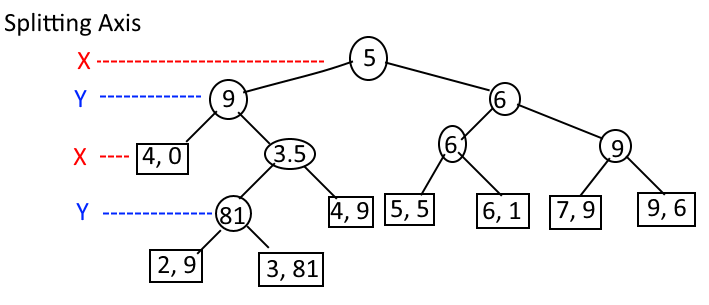

# 2. Introduction: make all the preprocessing personnel from the previous lesson.

- Import libraries.

In [ ]:
import pandas as pd
import numpy as np
import sklearn as sk
import re
import time
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

from sklearn.preprocessing import MinMaxScaler
from sklearn.linear_model import Lasso
from sklearn.pipeline import Pipeline

from sklearn.model_selection import train_test_split
from sklearn.metrics import silhouette_score, davies_bouldin_score

- Read training and test examples.

In [ ]:
!gdown 1v91d7L_OAHnXjtlZUhJiQbEMRVYi9UAu # train

Downloading...
From: https://drive.google.com/uc?id=1v91d7L_OAHnXjtlZUhJiQbEMRVYi9UAu
To: /content/train.json
100% 70.6M/70.6M [00:00<00:00, 101MB/s]


In [ ]:
train_data = pd.read_json("train.json")
train_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 49352 entries, 4 to 124009
Data columns (total 15 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   bathrooms        49352 non-null  float64
 1   bedrooms         49352 non-null  int64  
 2   building_id      49352 non-null  object 
 3   created          49352 non-null  object 
 4   description      49352 non-null  object 
 5   display_address  49352 non-null  object 
 6   features         49352 non-null  object 
 7   latitude         49352 non-null  float64
 8   listing_id       49352 non-null  int64  
 9   longitude        49352 non-null  float64
 10  manager_id       49352 non-null  object 
 11  photos           49352 non-null  object 
 12  price            49352 non-null  int64  
 13  street_address   49352 non-null  object 
 14  interest_level   49352 non-null  object 
dtypes: float64(3), int64(3), object(9)
memory usage: 6.0+ MB


In [ ]:
def cleaner(data, column_name:str) -> pd.DataFrame:  # функция для очистки от аутлайеров
  q1 = data[column_name].quantile(q=0.01)
  q2 = data[column_name].quantile(q=0.99)
  cleaned_data = data[(data[column_name] > q1) & (data[column_name] < q2)].reset_index(drop=True)
  return cleaned_data

- Preprocess interest level function.

In [ ]:
interest_codes = {
    "low": 0,
    "medium": 1,
    "high": 2
}
train_data["interest_level"] = train_data["interest_level"].map(interest_codes)

- Create features:  'Elevator', 'HardwoodFloors', 'CatsAllowed', 'DogsAllowed', 'Doorman', 'Dishwasher', 'NoFee', 'LaundryinBuilding', 'FitnessCenter', 'Pre-War', 'LaundryinUnit', 'RoofDeck', 'OutdoorSpace', 'DiningRoom', 'HighSpeedInternet', 'Balcony', 'SwimmingPool', 'LaundryInBuilding', 'NewConstruction', 'Terrace'.

In [ ]:
feature_list = ['Elevator', 'HardwoodFloors', 'CatsAllowed', 'DogsAllowed', 'Doorman', 'Dishwasher', 'NoFee',
                'LaundryinBuilding', 'FitnessCenter', 'Pre-War', 'LaundryinUnit', 'RoofDeck', 'OutdoorSpace',
                'DiningRoom', 'HighSpeedInternet', 'Balcony', 'SwimmingPool', 'LaundryInBuilding', 'NewConstruction', 'Terrace']

In [ ]:
def features_encoder(df, feature_list):
    pd.options.mode.copy_on_write = True
    pattern = re.compile(r'[\]\[\'\" ]+')

    for index, row in df.iterrows():
        features = []
        if not row['features']:
            features.append('')
        else:
            for string in row['features']:
                if not string.strip():
                    features.append('')
                    continue

                feature_string = pattern.sub('', string, 0)
                feature_string = feature_string.split(",")

                for feat in feature_string:
                    if not feat.strip():
                        features.append('')
                    else:
                        features.append(feat)

        for new_feat in feature_list:
          if new_feat in features:
              df.loc[index, new_feat] = 1
          else:
              df.loc[index, new_feat] = 0

    df = df.drop("features", axis=1)

    return df

In [ ]:
col_to_del = ['building_id', 'description', 'display_address',
              'listing_id', 'manager_id', 'photos',
              'street_address', 'created']
def del_columns(df:pd.DataFrame, col_list:list):
  for col in col_list:
    if col in df.columns:
        df = df.drop(col, axis=1)
  return df

In [ ]:
cleaned_train = cleaner(train_data, "price")
cleaned_train = del_columns(cleaned_train, col_to_del)
train_df = features_encoder(cleaned_train, feature_list)

In [ ]:
train_df.to_csv('train.csv', index=False)

In [ ]:
train_df.head()

,bathrooms,bedrooms,latitude,longitude,price,interest_level,Elevator,HardwoodFloors,CatsAllowed,DogsAllowed,...,LaundryinUnit,RoofDeck,OutdoorSpace,DiningRoom,HighSpeedInternet,Balcony,SwimmingPool,LaundryInBuilding,NewConstruction,Terrace
0,1.0,1,40.7108,-73.9539,2400,1,0.0,1.0,1.0,1.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
1,1.0,2,40.7513,-73.9722,3800,0,1.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,1.0,2,40.7575,-73.9625,3495,1,1.0,1.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,1.5,3,40.7145,-73.9425,3000,1,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,1.0,0,40.7439,-73.9743,2795,0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [ ]:
train_df = pd.read_csv('train.csv')
train_df.head()
X_train, X_test,Y_train, Y_test = train_test_split(train_df.drop("price", axis=1), train_df["price"], test_size=0.2, random_state=21)
X_train.shape

(38674, 25)

# 3. Implement the next method:

## - help functions.

In [ ]:
sil_results_list = []
dist_results_list = []
dbs_results_list = []
time_results_list = []
r2_lasso_results_list = []

In [ ]:
def preprocess_data_ll():
  train_df = pd.read_csv('train.csv')
  X_train, X_test,Y_train, Y_test = train_test_split(train_df.drop("price", axis=1),
                                                     train_df["price"],
                                                     test_size=0.2,
                                                     random_state=21)
  X_train_ll = X_train[["longitude", "latitude"]]
  X_test_ll = X_test[["longitude", "latitude"]]
  return X_train_ll, X_test_ll, Y_train, Y_test

def preprocess_data_lasso(train_pred:np.array, test_pred:np.array):
  train_df = pd.read_csv('train.csv')

  X_train, X_test, Y_train, Y_test = train_test_split(train_df.drop("price", axis=1),
                                                     train_df["price"],
                                                     test_size=0.2,
                                                     random_state=21)
  X_train["cluster_label"] = train_pred
  X_test["cluster_label"] = test_pred
  return X_train, X_test, Y_train, Y_test

In [ ]:
import copy

def calc_time(model_name: str, model, X: pd.DataFrame, time_results_list: list,
              data_type: str, n_runs: int = 3):
    times = []

    for _ in range(n_runs):
        current_model = copy.deepcopy(model)
        start_time = time.time()

        if hasattr(current_model, 'fit_predict'):
            current_model.fit_predict(X)
        elif hasattr(current_model, 'fit'):
            current_model.fit(X)

        times.append(time.time() - start_time)
        del current_model

    avg_time = sum(times) / len(times)

    time_results_list.append({
        'model': model_name,
        'time': avg_time,
        'data_type': data_type,
    })

    time_df = pd.DataFrame(time_results_list)
    display(time_df)

In [ ]:
def calc_silhoette(model_name: str, X, x_pred):
  X_np = np.asarray(X)
  s_score = silhouette_score(X_np, x_pred, metric="euclidean", random_state=21)
  metrics = {'Model': model_name, 'Sil_score': s_score}
  return metrics

In [ ]:
def calc_sil_train_test(model_name:str, X_train, X_test, train_pr, test_pr, sil_results_list):
  # train
  train_sil = calc_silhoette(f"{model_name} - train", X_train, train_pr)
  sil_results_list.append(train_sil)

  train_dbs = calc_db_score(f"{model_name} - train", X_train, train_pr)
  dbs_results_list.append(train_dbs)

  # test
  test_sil = calc_silhoette(f"{model_name} - test", X_test, test_pr)
  sil_results_list.append(test_sil)

  test_dbs = calc_db_score(f"{model_name} - test", X_test, test_pr)
  dbs_results_list.append(test_dbs)

  sil_results_df = pd.DataFrame(sil_results_list)
  display(sil_results_df)

In [ ]:
def calc_db_score(model_name: str, X, x_pred):
  X_np = np.asarray(X)
  dbs_score = davies_bouldin_score(X_np, x_pred)
  metrics = {'Model': model_name, 'Davies-Bouldin_score': dbs_score}
  return metrics

In [ ]:
def calc_feat_importance(pipeline, df, X_train, Y_train, X_test, Y_test, r2_list, model_name="lasso"):
  pipeline.fit(X_train, Y_train)
  train_r2 = pipeline.score(X_train, Y_train)
  test_r2 = pipeline.score(X_test, Y_test)

  r2_list.append({
            'model': f"{model_name}",
            'train_r2': train_r2,
            'test_r2': test_r2
        })
  r2_df = pd.DataFrame(r2_list)

  lasso_model = pipeline.named_steps['lasso']
  feature_names = df.columns.tolist()
  feature_names = X_train.columns.tolist()
  coefficients = lasso_model.coef_
  intercept = lasso_model.intercept_

  feat_df = pd.DataFrame({
      "feature": feature_names,
      "coef": coefficients,
      "abs_coef": abs(coefficients)
   })

  feat_df = feat_df.sort_values(["abs_coef"], ascending=False)
  return feat_df, r2_df

## - graph functions

In [ ]:
def plot_kmeans(df_ll: pd.DataFrame,
                 pred: np.array,
                 labels: np.array,
                 cluster_centres: np.array,
                 type_of_data: str,
                 type_of_alg: str):

  df_ll = df_ll.reset_index(drop=True)
  warnings.filterwarnings('ignore',
                           message='The palette list has more values.*')

  unique_labels = np.unique(labels)
  num_clusters = len(unique_labels)
  plt.figure(figsize=(12, 12))

  # palette
  if num_clusters > 0:
      palette = sns.color_palette("flare", num_clusters)
      label_to_color = {label: palette[i] for i, label in enumerate(unique_labels)}
  else:
      palette = []
      label_to_color = {}

  # scatter obj
  scatter = None
  ax = plt.gca()

  ## kmeans

  train_df_sns = df_ll.copy()
  train_df_sns["cluster"] = pred
  train_df_sns["is_centroid"] = False
  centroids_df = pd.DataFrame({
      "longitude": cluster_centres[:, 0],
      "latitude": cluster_centres[:, 1],
      "cluster": range(num_clusters),
      "is_centroid": True
  })
  plot_df = pd.concat([train_df_sns, centroids_df], ignore_index=True)
  plot_df = plot_df.reset_index(drop=True)
  scatter_data = plot_df[plot_df["is_centroid"] == False]
  scatter = sns.scatterplot(
      data=scatter_data,
      x="longitude",
      y="latitude",
      hue="cluster",
      palette=palette,
      alpha=0.8,
      s=30,
      edgecolor='white',
      linewidth=0.5,
      legend=False,
      ax=ax
  )

  centroid_data = plot_df[plot_df["is_centroid"] == True]
  sns.scatterplot(
      data=centroid_data,
      x="longitude",
      y="latitude",
      color="white",
      s=100,
      marker="o",
      edgecolor="black",
      linewidth=2,
      label="centroids",
      ax=ax
  )

  # legend
  legend_elements = []
  legend_elements.append(
      plt.Line2D([0], [0], marker='o', color='w',
                markerfacecolor='white', markersize=10,
                markeredgecolor='black', markeredgewidth=2,
                label=f'Centroids ({num_clusters})'))

  # кластеры через 5
  for i in range(0, num_clusters, 5):
      color = palette[i % len(palette)] if palette else 'gray'
      legend_elements.append(
          plt.Line2D([0], [0], marker='o', color='w',
                    markerfacecolor=color, markersize=8,
                    alpha=0.8, label=f'Cluster {i}')
      )

  plt.legend(
      handles=legend_elements,
      loc="upper left",
      ncol=1,
      fontsize=10,
      title="Clusters:",
      title_fontsize=11
  )

  plt.xlim([-74.050, -73.850])
  plt.ylim([40.650, 40.850])
  plt.xlabel("Longitude", fontsize=12)
  plt.ylabel("Latitude", fontsize=12)
  plt.title(f"K-Means: {num_clusters} clusters", fontsize=14)
  handles, labels_legend = scatter.get_legend_handles_labels()
  plt.tight_layout()
  plt.show()

In [ ]:
def plot_dbscan(df_ll: pd.DataFrame,
                 pred: np.array,
                 labels: np.array,
                 cluster_centres: np.array,
                 type_of_data: str,
                 type_of_alg: str):

    warnings.filterwarnings('ignore',
                           message='The palette list has more values.*')

    df_ll = df_ll.reset_index(drop=True)
    unique_labels = np.unique(pred[pred != -1])
    num_clusters = len(unique_labels)
    noise_count = np.sum(pred == -1)


    plt.figure(figsize=(12, 12))
      # palette
    if num_clusters > 0:
      palette = sns.color_palette("flare", num_clusters)
      label_to_color = {label: palette[i] for i, label in enumerate(unique_labels)}
    else:
      palette = []
      label_to_color = {}

    # scatter obj
    scatter = None
    ax = plt.gca()

    ## dbscan
    plot_df = df_ll.copy()
    plot_df["cluster"] = pred
    core_sample_indices = cluster_centres

    if core_sample_indices is not None and len(core_sample_indices) > 0:
            plot_df["is_core"] = False
            core_indices = np.array(core_sample_indices)
            valid_indices = core_indices[core_indices < len(plot_df)]
            plot_df.loc[valid_indices, "is_core"] = True
            has_core_points = True
            core_count = len(valid_indices)
    else:
      has_core_points = False
      core_count = 0


    noise_data = plot_df[plot_df["cluster"] == -1]
    cluster_data = plot_df[plot_df["cluster"] != -1]


    # все точки без label
    if not noise_data.empty:
      ax.scatter(
                noise_data["longitude"],
                noise_data["latitude"],
                color='lightgray',
                alpha=0.5,
                s=20,
                edgecolor='none'
            )

    if not cluster_data.empty:
      if has_core_points:
        core_data = cluster_data[cluster_data["is_core"] == True]
        border_data = cluster_data[cluster_data["is_core"] == False]
        border_count = len(border_data)

        # border точки
        if not border_data.empty:
          border_colors = [label_to_color.get(label, 'orange') for label in border_data["cluster"]]
          ax.scatter(
                  border_data["longitude"],
                  border_data["latitude"],
                  c=border_colors,
                  alpha=0.6,
                  s=20,
                  edgecolor='white',
                  linewidth=0.3
                  )

        # core точки
        if not core_data.empty:
          core_colors = [label_to_color.get(label, 'gray') for label in core_data["cluster"]]
          ax.scatter(
                    core_data["longitude"],
                    core_data["latitude"],
                    c=core_colors,
                    alpha=0.9,
                    s=50,
                    edgecolor='black',
                    linewidth=1
                    )
      else:
        # нет core точек - рисуем все точки кластера
        cluster_colors = [label_to_color.get(label, 'gray') for label in cluster_data["cluster"]]
        ax.scatter(
                  cluster_data["longitude"],
                  cluster_data["latitude"],
                  c=cluster_colors,
                  alpha=0.7,
                  s=30,
                  edgecolor='white',
                  linewidth=0.5
                )

      # добавляем пустые точки с labels для легенды
      legend_elements = []

      if noise_count > 0:
            legend_elements.append(
                plt.Line2D([0], [0], marker='o', color='w',
                          markerfacecolor='black', markersize=8,
                          alpha=0.3, label=f'Noise ({noise_count})')
            )

      if has_core_points and core_count > 0:
            legend_elements.append(
                plt.Line2D([0], [0], marker='o', color='w',
                          markerfacecolor='gray', markersize=10,
                          alpha=0.9, markeredgecolor='black', markeredgewidth=1,
                          label=f'Core points ({core_count})')
            )

            if border_count > 0:
                legend_elements.append(
                    plt.Line2D([0], [0], marker='o', color='w',
                              markerfacecolor='orange', markersize=6,
                              alpha=0.6, markeredgecolor='white', markeredgewidth=0.3,
                              label=f'Border points ({border_count})')
                )

    scatter = ax

    plt.xlim([-74.050, -73.850])
    plt.ylim([40.650, 40.850])
    plt.xlabel("Longitude", fontsize=12)
    plt.ylabel("Latitude", fontsize=12)
    plt.title(f"DBSCAN: {num_clusters} clusters, {noise_count} noise, {core_count if 'core_count' in locals() else 0} core points", fontsize=14)

    handle = None
    if scatter is not None:
      if legend_elements:
                plt.legend(
                    handles=legend_elements,
                    loc="upper left",
                    ncol=1,
                    fontsize=10,
                    title="Clusters:",
                    title_fontsize=11
                )
      else:
        handles, labels_legend = ax.get_legend_handles_labels()

    #if handles:
        #plt.legend(handles, labels_legend, loc="upper left", fontsize=10)

    plt.tight_layout()
    plt.show()

In [ ]:
def plot_agglomerative(X, labels):
    X = np.asarray(X)
    plt.figure(figsize=(8, 6))
    plt.scatter(X[:, 0], X[:, 1], c=labels, cmap='tab20', s=20, alpha=0.7)

    plt.xlim([-74.050, -73.850])
    plt.ylim([40.650, 40.850])
    plt.xlabel("Longitude", fontsize=12)
    plt.ylabel("Latitude", fontsize=12)

    plt.title(f"Agglomerative Clustering - {len(np.unique(labels))} clusters")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

In [ ]:
def plot_gmm(X, pred, means, title="GMM Clustering"):
    X = np.asarray(X)
    plt.figure(figsize=(8, 6))
    plt.scatter(X[:, 0], X[:, 1], c=pred, cmap='viridis', s=10, alpha=0.5)
    plt.scatter(means[:, 0], means[:, 1], s=100, c='white', marker='o',edgecolor="black",linewidth=2, label='Centers')

    plt.xlim([-74.050, -73.850])
    plt.ylim([40.650, 40.850])
    plt.xlabel("Longitude", fontsize=12)
    plt.ylabel("Latitude", fontsize=12)

    plt.title(title)
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

## - K-means algorithm.

In [ ]:
class MyKMeans:
  def __init__(self, n_clusters, init="forgy", random_state=21, max_iter=100):
    self.n_clusters = n_clusters
    self.init = init
    self.random_state = random_state
    self.max_iter = max_iter
    np.random.seed(self.random_state)

  def _centroid_init(self, X):
    n_samples, n_feats = X.shape
    num_clusters = self.n_clusters
    if self.init == "forgy":
      # рандомно выбираем из всех точек данных нужное кол-во кластеров
      centr_num = np.random.choice(n_samples, num_clusters, replace=False)
      return X[centr_num].copy() # (num_clusters, n_feats)

    elif self.init == "random_partition":
      # каждую точку данных присваиваем рандомному кластеру, находим среднее по каждому - это и будут центроиды
      cl_assignments = np.random.randint(0, num_clusters, n_samples) # array
      centroids = np.zeros((num_clusters, n_feats))

      for cluster_idx in range(num_clusters):
        in_cluster = X[cl_assignments == cluster_idx] # bool array
        if len(in_cluster) > 0: # больше одной точки
          centroids[cluster_idx] = np.mean(in_cluster, axis=0)
        else:
          random_idx = np.random.randint(0, n_samples)
          centroids[cluster_idx] = X[random_idx]
      return centroids # (num_clusters, n_feats)

    ## add k-means++
    elif self.init=="kmeans++":
      centroids = np.zeros((num_clusters, n_feats))
      first_centr = np.random.choice(n_samples, 1)
      centroids[0] = X[first_centr]

      for k in range(1, num_clusters):
        first_centr_distances = self._calc_euclidean(X, centroids[:k])
        min_distances = np.min(first_centr_distances, axis=1)
        probabilities = min_distances ** 2 / np.sum(min_distances ** 2)

        next_idx = np.random.choice(n_samples, p=probabilities)
        centroids[k] = X[next_idx]

    return centroids

  def fit(self, X):
    X = np.asarray(X)
    self.n_feats_ = X.shape[1]
    centroids = self._centroid_init(X)

    for iter in range(self.max_iter):
      old_centroids = centroids.copy()
      cluster_assignments = self._assign(X, centroids)
      centroids = self._update(X, cluster_assignments)

      if self._check_conv(old_centroids, centroids):
        print(f"Сошлось на итерации {iter}")
        break

    self.cluster_centres_ = centroids
    self.labels_ = cluster_assignments
    self.inertia_ = self._calc_distortion(X, self.labels_, self.cluster_centres_)
    return self

  def predict(self, X):
    X = np.asarray(X)
    if not hasattr(self, 'cluster_centres_'):
      raise Exception("Модель не обучена. Сначала вызовите fit().")
    return self._assign(X, self.cluster_centres_)

  def _assign(self, X, centroids):
    centr_distances = self._calc_euclidean(X, centroids) # (n_samples, num_clusters)
    cluster_assignments = np.argmin(centr_distances, axis=1) # нашли номер кластера для каждой точки
    return cluster_assignments # (n_samples)

  def _update(self, X, cluster_assignments):
    n_feats = X.shape[1]
    new_centroids = np.zeros((self.n_clusters, n_feats))
    for cl_idx in range(self.n_clusters):
      mask = (cluster_assignments == cl_idx)

      if np.any(mask):
        new_centroids[cl_idx] = np.mean(X[mask], axis=0)
      else:
        random_idx = np.random.randint(0, X.shape[0])
        new_centroids[cl_idx] = X[random_idx]

    return new_centroids

  def _calc_euclidean(self, X, Y):
    # подаем два набора точек, получаем матрицу расстояний
    # via broadcasting
    # X[:, np.newaxis, :] - форма (n_samples, 1, n_feat)
    # centr[np.newaxis, :, :] - форма (1, num_clusters, n_feat)

    diff = X[:, np.newaxis, :] - Y[np.newaxis, :, :] # (n_samples, num_clusters, n_feat)
    squared_diff = np.sum(diff**2, axis=2) #(n_samples, num_clusters)
    return np.sqrt(squared_diff)

  def _check_conv(self, old_centroids, new_centroids):
    tol = 1e-4
    distances = np.linalg.norm(old_centroids - new_centroids, axis=1, ord=2)
    return np.all(distances < tol)

  def _calc_distortion(self, X, x_pred, x_centers):
    x_pred_np = np.asarray(x_pred)
    x_centers_np = np.asarray(x_centers)
    centroids = x_centers_np[x_pred_np] # массив центроидов для каждой точки
    total_distortion = np.sum((X - centroids) ** 2)
    return total_distortion

- Fit cluster algorithm with 30 clusters on 'longitude' and 'latitude' features, make prediction for training and test samples.


In [ ]:
X_train_ll, X_test_ll, Y_train, Y_test = preprocess_data_ll()
my_kmeans = MyKMeans(n_clusters=30, init="kmeans++", random_state=21, max_iter=100)
#my_kmeans = MyKMeans(n_clusters=30, init="forgy", random_state=21, max_iter=100)
my_kmeans.fit(X_train_ll)

Сошлось на итерации 27


In [ ]:
train_pred = my_kmeans.predict(X_train_ll)
test_pred = my_kmeans.predict(X_test_ll)

- Compute Silhouette score and Distortion.

In [ ]:
calc_sil_train_test("My_KMeans", X_train_ll, X_test_ll, train_pred, test_pred, sil_results_list)

,Model,Sil_score
0,My_KMeans - train,0.453716
1,My_KMeans - test,0.453186


In [ ]:
my_kmeans_distortion = my_kmeans.inertia_
dist_results_list.append({
    'model': 'My_KMeans',
    'distortion': f"{my_kmeans_distortion:.4f}"
})
float(my_kmeans_distortion)

5.0255575186807535

- Draw result with scatterplot, try to analyze it.

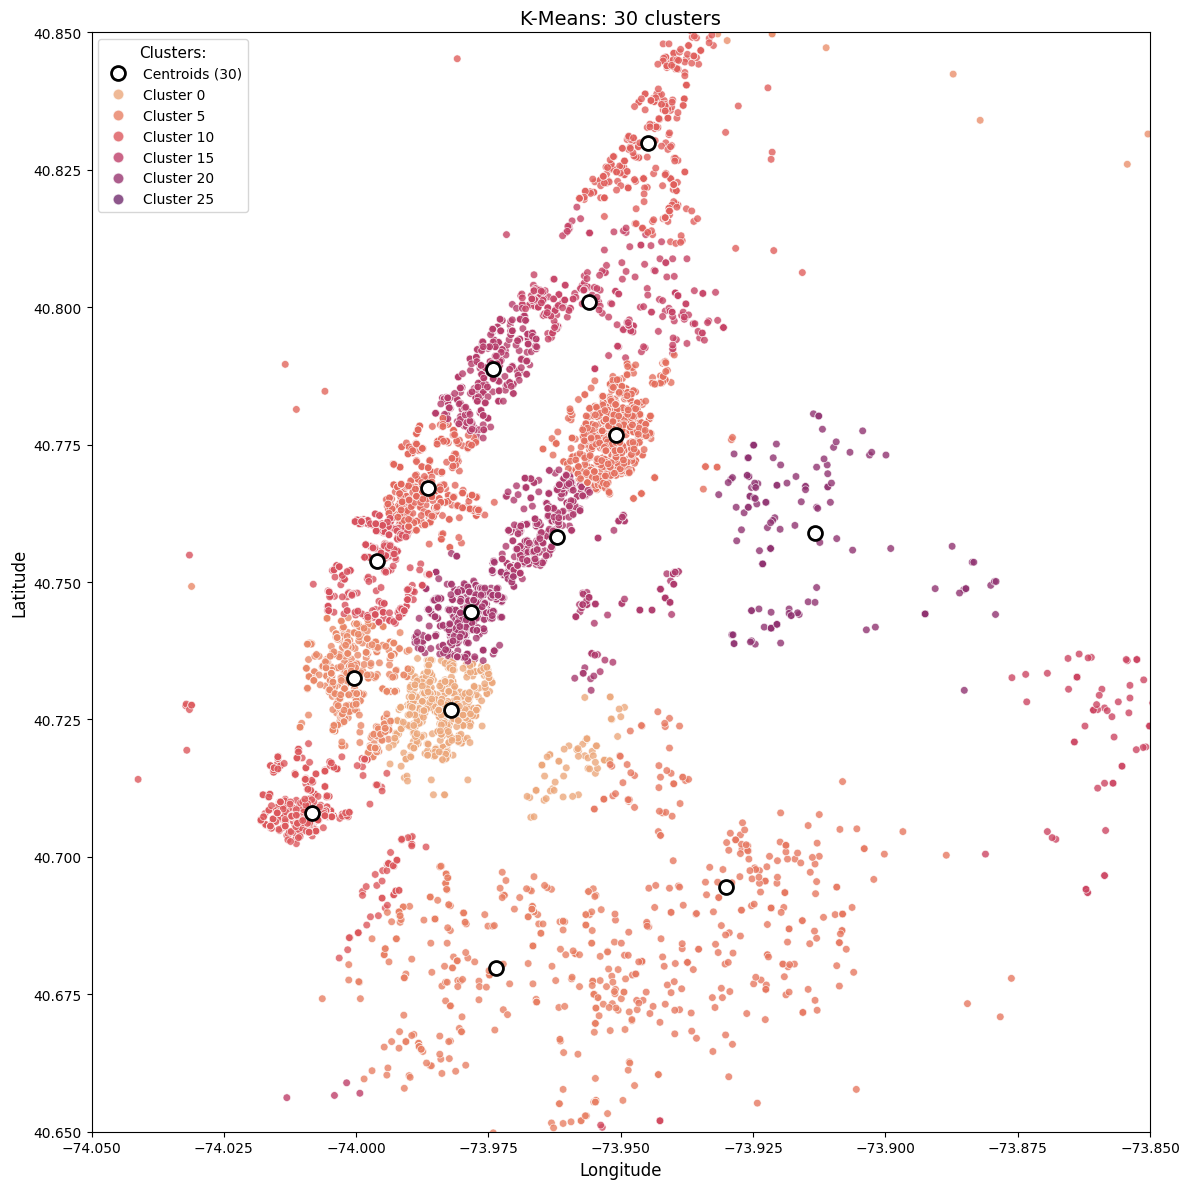

In [ ]:
plot_kmeans(df_ll=X_test_ll,
             pred=test_pred,
             labels=my_kmeans.labels_,
             cluster_centres = my_kmeans.cluster_centres_,
             type_of_data = "test",
             type_of_alg="k_means")

In [ ]:
#plot_scatter(df_ll=X_train_ll,
#             pred=train_pred,
#             labels=my_kmeans.labels_,
#             cluster_centres = my_kmeans.cluster_centres_,
#             type_of_data = "train",
#             type_of_alg="k_means")

In [ ]:
my_kmeans = MyKMeans(n_clusters=30, init="kmeans++", random_state=21, max_iter=100)
calc_time("My_KMeans", my_kmeans, X_train_ll, time_results_list, data_type="train")

Сошлось на итерации 27
Сошлось на итерации 34
Сошлось на итерации 13


,model,time,data_type
0,My_KMeans,0.85555,train


- Add the label of the cluster as a feature in the Lasso Regression with MinMaxScaller.

In [ ]:
train_df = pd.read_csv('train.csv')
X_train, X_test,Y_train, Y_test = train_test_split(train_df.drop("price", axis=1),
                                                     train_df["price"],
                                                     test_size=0.2,
                                                     random_state=21)


pipe = Pipeline([("scaler", MinMaxScaler(feature_range=(0, 1))),
                ("lasso", Lasso(fit_intercept=True, random_state=21))])

pipe.fit(X_train, Y_train).score(X_test, Y_test) # r2 score by default for lasso
base_coef_df, base_r2_df = calc_feat_importance(pipe, X_train, X_train, Y_train, X_test, Y_test,
                                         r2_lasso_results_list, model_name="lasso_base")

In [ ]:
X_train, X_test, Y_train, Y_test = preprocess_data_lasso(train_pred, test_pred)
#display(X_train.head())
#display(X_test.head())
pipe.fit(X_train, Y_train).score(X_test, Y_test)

0.6196873044694556

 - Print the feature importance as the feature weight from the Lasso.


In [ ]:
my_kmeans_coef_df, my_kmeans_r2_df = calc_feat_importance(pipe, X_train, X_train, Y_train, X_test, Y_test,
                                         r2_lasso_results_list, model_name="lasso_my_kmeans")
display(my_kmeans_coef_df.head(10))

,feature,coef,abs_coef
0,bathrooms,14350.057433,14350.057433
1,bedrooms,3884.012636,3884.012636
4,interest_level,-849.167406,849.167406
9,Doorman,579.611190,579.611190
15,LaundryinUnit,425.281292,425.281292
25,cluster_label,-351.845268,351.845268
5,Elevator,227.485458,227.485458
13,FitnessCenter,211.172654,211.172654
19,HighSpeedInternet,-175.233340,175.233340
12,LaundryinBuilding,-174.928717,174.928717


In [ ]:
display(my_kmeans_r2_df)

,model,train_r2,test_r2
0,lasso_base,0.601729,0.615800
1,lasso_my_kmeans,0.605387,0.619687


- Топ-6 фичей: bathrooms, bedrooms, interest_level, Doorman, Laundry, cluster_label.

 - Import K-means from sklearn and compare results.

In [ ]:
from sklearn.cluster import KMeans
#my_kmeans = MyKMeans(n_clusters=30, init="kmeans++", random_state=21, max_iter=100)
sk_kmeans = KMeans(n_clusters=30, init="random", random_state=21, max_iter=100) #- тут будет сходиться с чек-листом
#sk_kmeans = KMeans(n_clusters=30, init="k-means++", random_state=21, max_iter=100)
sk_kmeans.fit(X_train_ll)
train_pred_sk = sk_kmeans.predict(X_train_ll)
test_pred_sk = sk_kmeans.predict(X_test_ll)

In [ ]:
sk_kmeans_distortion = sk_kmeans.inertia_
dist_results_list.append({
    'model': 'Sk_KMeans',
    'distortion': f"{sk_kmeans_distortion:.4f}"
})

float(sk_kmeans_distortion)

4.994633764046534

In [ ]:
calc_sil_train_test("My_KMeans", X_train_ll, X_test_ll, train_pred_sk, test_pred_sk, sil_results_list)

,Model,Sil_score
0,My_KMeans - train,0.453716
1,My_KMeans - test,0.453186
2,My_KMeans - train,0.449124
3,My_KMeans - test,0.454895


- Метрики Silhoette score и distortion (атрибут inertia_ в sklearn) сопоставимы при одинаковых параметрах запуска;
- sklearn версия быстрее за счет внутренних оптимизаций в библиотеке.

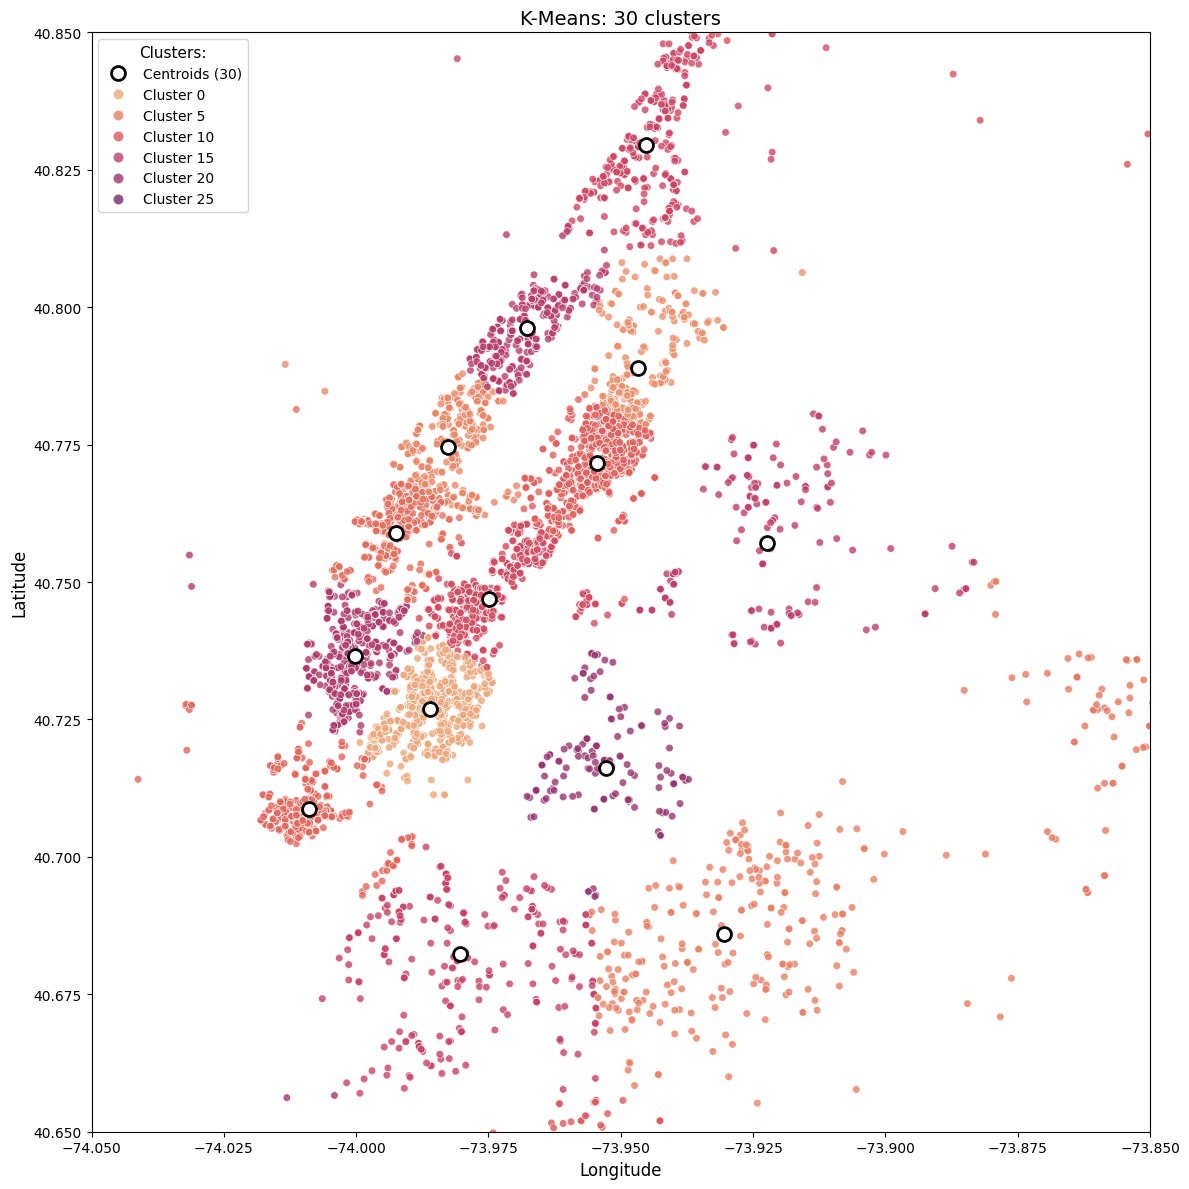

In [ ]:
plot_kmeans(df_ll=X_test_ll,
             pred=test_pred_sk,
             labels=sk_kmeans.labels_,
             cluster_centres=sk_kmeans.cluster_centers_,
             type_of_data="test",
             type_of_alg="k_means")

In [ ]:
#plot_scatter(df_ll=X_train_ll,
#             pred=train_pred_sk,
#             labels=sk_kmeans.labels_,
#             cluster_centres=sk_kmeans.cluster_centers_,
#             type_of_data="train",
#             type_of_alg="k_means")

- Визуализации кластеризаций также выглядят схоже и для тренировочной, и для тестовой выборок.

In [ ]:
KMeans(n_clusters=30, init="k-means++", random_state=21, max_iter=100)
calc_time("Sk_KMeans", sk_kmeans, X_train_ll, time_results_list, data_type="train")

,model,time,data_type
0,My_KMeans,0.85555,train
1,Sk_KMeans,0.11272,train


In [ ]:
X_train, X_test, Y_train, Y_test = preprocess_data_lasso(train_pred_sk, test_pred_sk)
#display(X_train.head())
#display(X_test.head())

In [ ]:
sk_kmeans_coef_df, sk_kmeans_r2_df = calc_feat_importance(pipe, X_train, X_train, Y_train, X_test, Y_test,
                                         r2_lasso_results_list, model_name="lasso_sk_kmeans")
display(sk_kmeans_coef_df)
#display(my_kmeans_coef_df.head(10))

,feature,coef,abs_coef
0,bathrooms,14282.981779,14282.981779
1,bedrooms,3907.610678,3907.610678
4,interest_level,-836.426309,836.426309
9,Doorman,564.498416,564.498416
15,LaundryinUnit,435.015934,435.015934
25,cluster_label,291.208152,291.208152
5,Elevator,204.873113,204.873113
13,FitnessCenter,199.577892,199.577892
19,HighSpeedInternet,-194.955079,194.955079
12,LaundryinBuilding,-183.329332,183.329332


- По топ-6 коэффициентам моя реализация и оригинальная также близки (с инициализацией kmeans++ признак далее важный по Лассо). Считается, что kmeans++ метод более качественно инициализирует центроиды, и по сравнению с рандомной инициализацией лучше находит близкое к глобально оптимальному разбиение данных.

- В чек-листе для модели KMeans, по-видимому, используется инициализация по Forgy (random в sklearn) - когда из всех точек данных рандомно выбираются k кластеров. Такой метод инициализации неустойчив, есть риск попасть в локальный оптимум + сильная вариативность между запусками (даже если по умолчанию запускается 10 раз при таком способе инициализации).

- Расхождения в важности нового признака для разных способов инициализаций в целом указывает, что данный признак может быть рискованно использовать в дальнейшем для предсказания в моделях регрессии.

# 4. Do the same steps, but with the DBScan algorithm
## - (try different parameters for better Lasso model quality).

In [ ]:
from collections import deque
from sklearn.neighbors import KDTree

class MyDBSCAN:
    def __init__(self, eps=0.001, min_samples=5, metric="euclidean", leaf_size=40):
        self.eps = eps
        self.min_samples = min_samples
        self.metric = metric
        self.leaf_size = leaf_size

    def fit(self, X):
        X = np.asarray(X)
        n = X.shape[0]

        self.tree = KDTree(X, leaf_size=self.leaf_size, metric=self.metric)

        labels = np.full(n, -1)
        visited = np.zeros(n, dtype=bool)
        is_core = np.zeros(n, dtype=bool)
        cluster_id = 0

        for i in range(n):
            if visited[i]:
                continue
            visited[i] = True

            #neighbors = self.tree.query_radius(X[i:i+1], r=np.nextafter(self.eps, np.inf))[0]
            neighbors = self.tree.query_radius(X[i:i+1], r=self.eps)[0]

            if len(neighbors) < self.min_samples:
                labels[i] = -1
            else:
                is_core[i] = True
                self._expand_cluster(X, labels, visited, is_core, neighbors, cluster_id)
                cluster_id += 1

        self.labels_ = labels
        self.n_clusters_ =  cluster_id


        self.core_sample_indices_ = np.where(is_core)[0]
        if len(self.core_sample_indices_) > 0:
            self.components_ = X[self.core_sample_indices_]
        else:
            self.components_ = np.empty((0, X.shape[1]))

        return self.labels_

    def _expand_cluster(self, X, labels, visited, is_core, neighbors, cluster_id):
        queue = deque(neighbors)
        while queue:
            point_idx = queue.popleft()
            if not visited[point_idx]:
                visited[point_idx] = True
                #new_neighbors = self.tree.query_radius(X[point_idx:point_idx+1], r=np.nextafter(self.eps, np.inf))[0]
                new_neighbors = self.tree.query_radius(X[point_idx:point_idx+1], r=self.eps)[0]

                if len(new_neighbors) >= self.min_samples:
                  is_core[point_idx] = True
                  queue.extend(new_neighbors)

            if labels[point_idx] == -1:
                labels[point_idx] = cluster_id

    def fit_predict(self, X):
        return self.fit(X)

In [ ]:
X_train_ll, X_test_ll, Y_train, Y_test = preprocess_data_ll()
my_dbscan = MyDBSCAN(eps=0.001, min_samples=5)
my_db_train_pred = my_dbscan.fit(X_train_ll)
train_core_points = my_dbscan.components_
train_core_indices = my_dbscan.core_sample_indices_

In [ ]:
my_db_test_pred = my_dbscan.fit_predict(X_test_ll)
test_core_points = my_dbscan.components_
test_core_indices = my_dbscan.core_sample_indices_

In [ ]:
calc_sil_train_test("My_DBSCAN", X_train_ll, X_test_ll, my_db_train_pred, my_db_test_pred, sil_results_list)

,Model,Sil_score
0,My_KMeans - train,0.453716
1,My_KMeans - test,0.453186
2,My_KMeans - train,0.449124
3,My_KMeans - test,0.454895
4,My_DBSCAN - train,-0.112752
5,My_DBSCAN - test,-0.006866


In [ ]:
#plot_scatter(
#    df_ll=X_train_ll,
#    pred=db_train_pred,
#    labels=db_train_pred,
#    cluster_centres=my_dbscan.core_sample_indices_,
#    type_of_data="train",
#    type_of_alg="dbscan"
#)

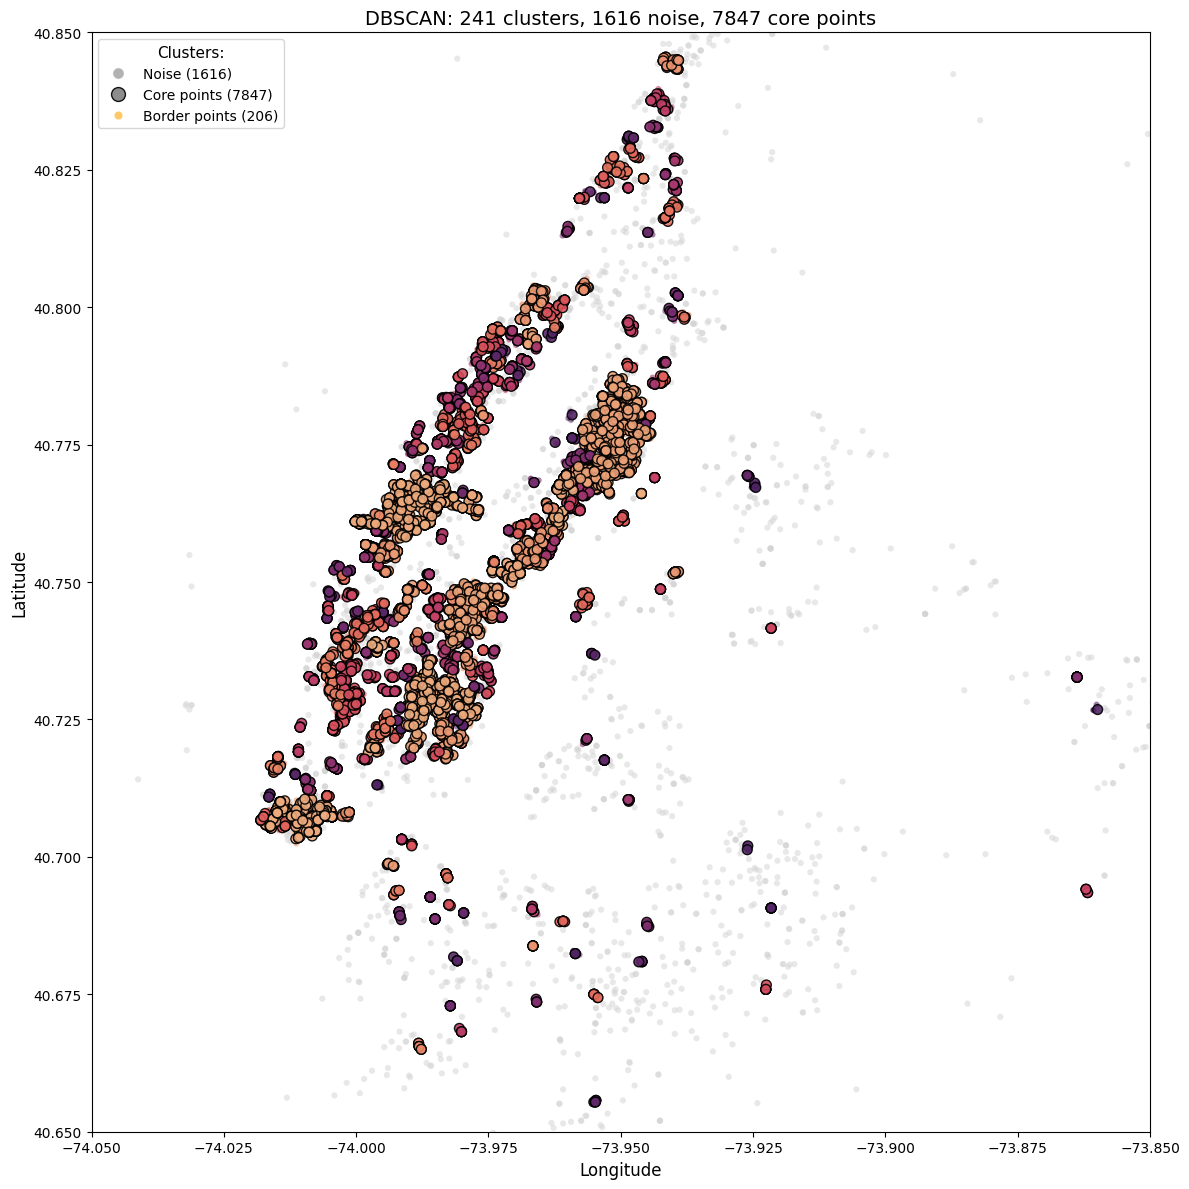

In [ ]:
plot_dbscan(
    df_ll=X_test_ll,
    pred=my_db_test_pred,
    labels=my_db_test_pred,
    cluster_centres=my_dbscan.core_sample_indices_,
    type_of_data="test",
    type_of_alg="dbscan"
)

In [ ]:
my_dbscan = MyDBSCAN(eps=0.001, min_samples=5)
calc_time("My_DBSCAN", my_dbscan, X_train_ll, time_results_list, data_type="train")

,model,time,data_type
0,My_KMeans,0.855550,train
1,Sk_KMeans,0.112720,train
2,My_DBSCAN,7.458416,train
3,Sk_DBSCAN,0.332626,train
4,Sk_Agg_Cl,5.011408,train(10000 samples)
5,My_GM,33.664170,train
6,Sk_GM,9.223363,train
7,My_DBSCAN,7.251193,train


In [ ]:
X_train, X_test, Y_train, Y_test = preprocess_data_lasso(my_db_train_pred, my_db_test_pred)
#display(X_train.head())
#display(X_test.head())

In [ ]:
my_dbscan_coef_df, my_dbscan_r2_df = calc_feat_importance(pipe, X_train, X_train, Y_train, X_test, Y_test,
                                         r2_lasso_results_list, model_name="lasso_my_dbscan")
display(my_dbscan_coef_df.head(10))

,feature,coef,abs_coef
0,bathrooms,14310.596469,14310.596469
1,bedrooms,3900.518619,3900.518619
4,interest_level,-843.804092,843.804092
9,Doorman,533.992567,533.992567
25,cluster_label,-511.983683,511.983683
15,LaundryinUnit,442.592066,442.592066
5,Elevator,214.549942,214.549942
13,FitnessCenter,207.986359,207.986359
12,LaundryinBuilding,-190.243373,190.243373
22,LaundryInBuilding,-180.493883,180.493883


In [ ]:
display(my_dbscan_r2_df)

,model,train_r2,test_r2
0,lasso_base,0.601729,0.615800
1,lasso_my_kmeans,0.605387,0.619687
2,lasso_sk_kmeans,0.601813,0.615850
3,lasso_my_dbscan,0.605449,0.607750
4,lasso_sk_dbscan,0.605449,0.607750
5,lasso_sk_agcl,0.607272,0.620427
6,lasso_my_gm,0.604754,0.616503
7,lasso_sk_gm,0.603127,0.618474
8,lasso_sk_kmeans_3f,0.608678,0.621342
9,lasso_sk_dbscan_3f,0.602929,0.614146


In [ ]:
from sklearn.cluster import DBSCAN
sk_dbscan = DBSCAN(eps=0.001, min_samples=5, metric="euclidean", leaf_size=40, algorithm="kd_tree", n_jobs=-1)

sk_db_test_pred = sk_dbscan.fit_predict(X_test_ll)
sk_test_core_points = sk_dbscan.components_

sk_db_train_pred = sk_dbscan.fit_predict(X_train_ll)
sk_train_core_points = sk_dbscan.components_

In [ ]:
calc_sil_train_test("My_DBSCAN", X_train_ll, X_test_ll, sk_db_train_pred, sk_db_test_pred, sil_results_list)

,Model,Sil_score
0,My_KMeans - train,0.453716
1,My_KMeans - test,0.453186
2,My_KMeans - train,0.449124
3,My_KMeans - test,0.454895
4,My_DBSCAN - train,-0.112752
5,My_DBSCAN - test,-0.006866
6,My_DBSCAN - train,-0.112752
7,My_DBSCAN - test,-0.006866
8,Sk_Agg_Cl - train,0.434214
9,Sk_Agg_Cl - test,0.431026


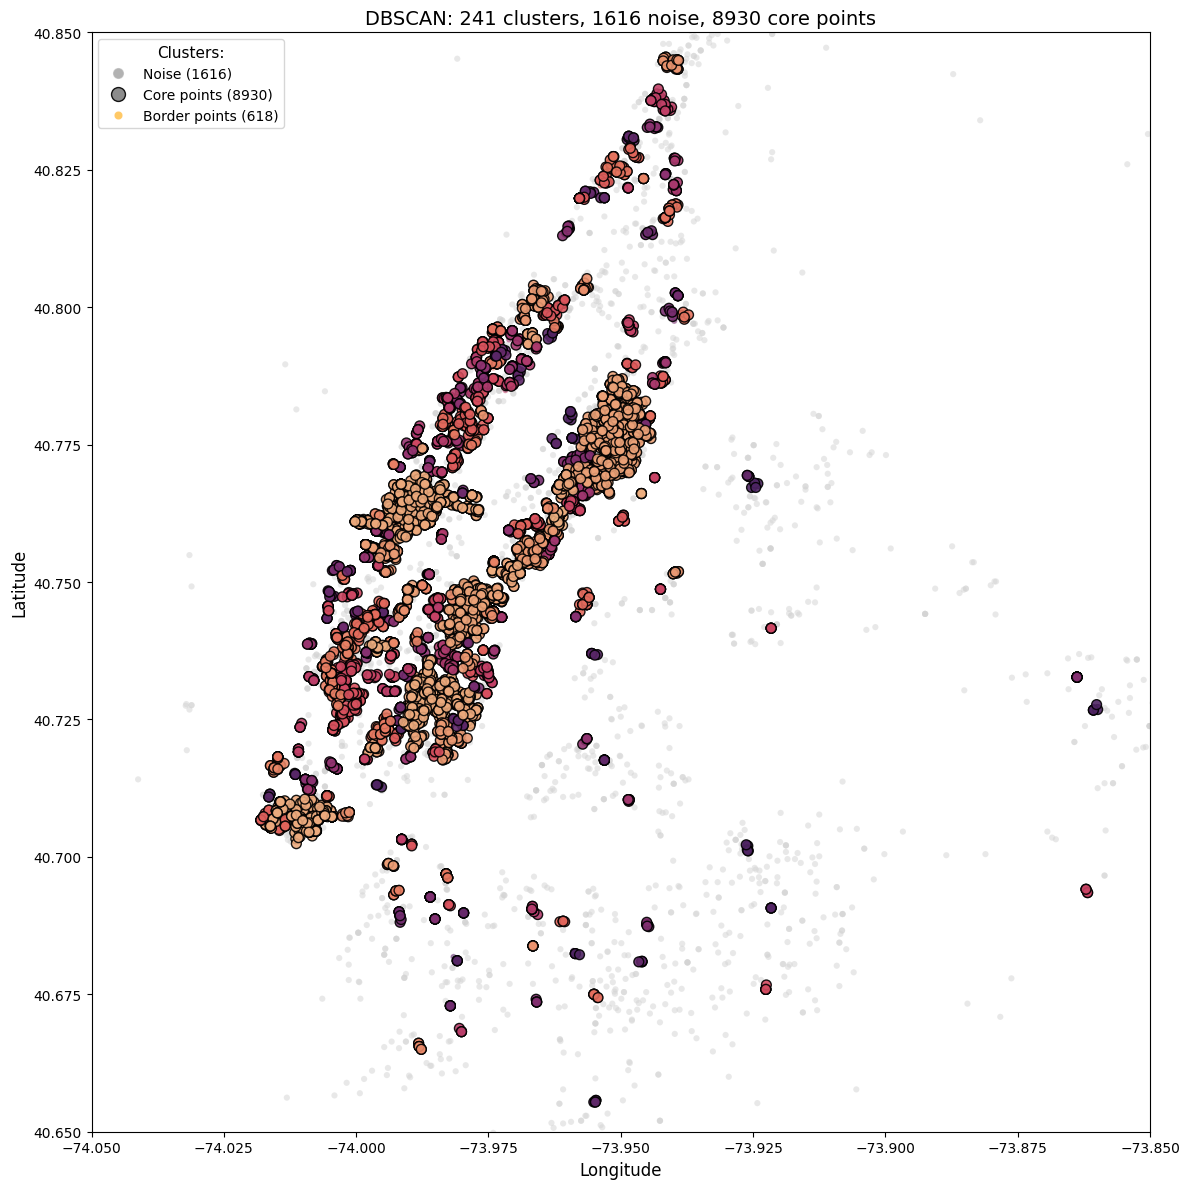

In [ ]:
plot_dbscan(
    df_ll=X_test_ll,
    pred=sk_db_test_pred,
    labels=sk_db_test_pred,
    cluster_centres=sk_dbscan.core_sample_indices_,
    type_of_data="test",
    type_of_alg="dbscan"
)

In [ ]:
#plot_scatter(
#    df_ll=X_train_ll,
#    pred=sk_db_train_pred,
#    labels=sk_db_train_pred,
#    cluster_centres=sk_dbscan.core_sample_indices_,
#    type_of_data="train",
#    type_of_alg="dbscan"
#)

In [ ]:
sk_dbscan = DBSCAN(eps=0.001, min_samples=5, metric="euclidean", leaf_size=40, algorithm="kd_tree", n_jobs=-1)
calc_time("Sk_DBSCAN", sk_dbscan , X_train_ll, time_results_list, data_type="train")

,model,time,data_type
0,My_KMeans,0.855550,train
1,Sk_KMeans,0.112720,train
2,My_DBSCAN,7.458416,train
3,Sk_DBSCAN,0.332626,train


In [ ]:
X_train, X_test, Y_train, Y_test = preprocess_data_lasso(sk_db_train_pred, sk_db_test_pred)
#display(X_train.head())
#display(X_test.head())

In [ ]:
sk_dbscan_coef_df, sk_dbscan_r2_df = calc_feat_importance(pipe, X_train, X_train, Y_train, X_test, Y_test,
                                         r2_lasso_results_list,
                                         model_name="lasso_sk_dbscan")
display(sk_dbscan_coef_df.head(10))
#display(my_dbscan_coef_df.head(10))

,feature,coef,abs_coef
0,bathrooms,14310.596469,14310.596469
1,bedrooms,3900.518619,3900.518619
4,interest_level,-843.804092,843.804092
9,Doorman,533.992567,533.992567
25,cluster_label,-511.983683,511.983683
15,LaundryinUnit,442.592066,442.592066
5,Elevator,214.549942,214.549942
13,FitnessCenter,207.986359,207.986359
12,LaundryinBuilding,-190.243373,190.243373
22,LaundryInBuilding,-180.493883,180.493883


In [ ]:
display(sk_dbscan_r2_df)

,model,train_r2,test_r2
0,lasso_base,0.601729,0.615800
1,lasso_my_kmeans,0.605387,0.619687
2,lasso_sk_kmeans,0.601813,0.615850
3,lasso_my_dbscan,0.605449,0.607750
4,lasso_sk_dbscan,0.605449,0.607750


- И оригинальный (с использованием алгоритма поиска соседей через кд-дерревья), и реализованный мной DBSCAN пи одинаковых параметрах различают в тестовых данных 241 кластер; кол-во найденных core, border, noise points также совпадает.

- По времени работы моя реализация медленнее sk_DBSCAN.

- Признак принадлежности к кластеру входит в топ-6 фич как в случае предсказаний моей реализации, так и в случае sklearn DBSCAN (коэффициенты важности фич также совпадают).

# 5. Next, do the same steps as before, but the implementation of the AgglomerativeClustering algorithm is not mandatory for you, you can import it from sklearn.

In [ ]:
X_train_ll, X_test_ll, Y_train, Y_test = preprocess_data_ll()
X_train_ll.shape

(38674, 2)

In [ ]:
from sklearn.cluster import AgglomerativeClustering
from sklearn.neighbors import kneighbors_graph

# падает при расчете расстояний между всеми точками, поэтому возьмем 70 ближайших соседей
connectivity_matrix = kneighbors_graph(X_train_ll, n_neighbors=70, mode='connectivity', include_self=False)
sk_agcl = AgglomerativeClustering(n_clusters=30, metric='euclidean', linkage='ward', connectivity=connectivity_matrix)

X_train_ll, X_test_ll, Y_train, Y_test = preprocess_data_ll()
sk_agcl.fit(X_train_ll)
sk_agcl_train_pred  = sk_agcl.labels_

In [ ]:
X_combined = np.vstack([X_train_ll, X_test_ll])
connectivity_matrix = kneighbors_graph(X_combined, n_neighbors=80, mode='connectivity', include_self=False)
sk_agcl = AgglomerativeClustering(n_clusters=30, metric='euclidean', linkage='ward', connectivity=connectivity_matrix)

all_labels = sk_agcl.fit_predict(X_combined)

sk_agcl_test_pred = all_labels[len(X_train):]

/usr/local/lib/python3.12/dist-packages/sklearn/cluster/_agglomerative.py:325: UserWarning: the number of connected components of the connectivity matrix is 3 > 1. Completing it to avoid stopping the tree early.
  connectivity, n_connected_components = _fix_connectivity(


In [ ]:
#sk_agcl.fit_predict(X_test_ll)
#sk_agcl_test_pred = sk_agcl.labels_

In [ ]:
calc_sil_train_test("Sk_Agg_Cl", X_train_ll, X_test_ll, sk_agcl_train_pred, sk_agcl_test_pred, sil_results_list)


,Model,Sil_score
0,My_KMeans - train,0.453716
1,My_KMeans - test,0.453186
2,My_KMeans - train,0.449124
3,My_KMeans - test,0.454895
4,My_DBSCAN - train,-0.112752
5,My_DBSCAN - test,-0.006866
6,My_DBSCAN - train,-0.112752
7,My_DBSCAN - test,-0.006866
8,Sk_Agg_Cl - train,0.434214
9,Sk_Agg_Cl - test,0.431026


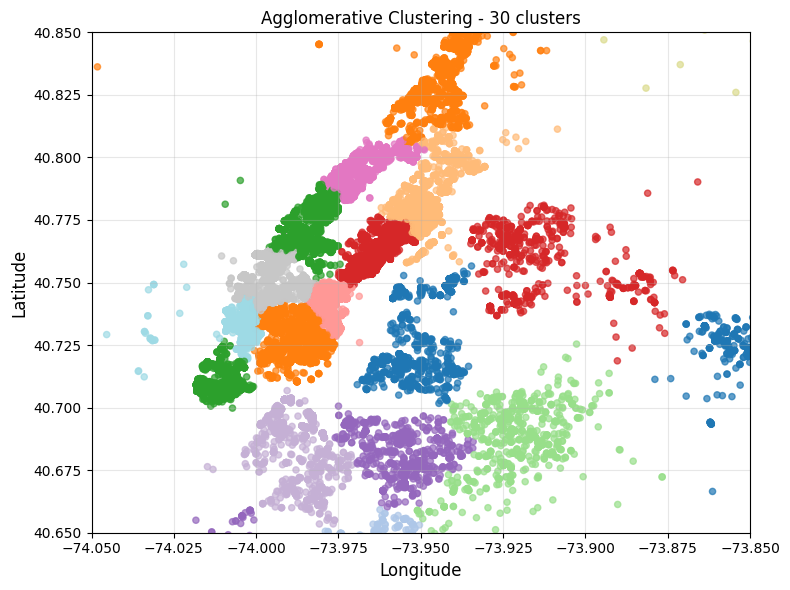

In [ ]:
# visualization of Aggl Cl
plot_agglomerative(X_train_ll, sk_agcl_train_pred)

In [ ]:
sk_agcl = AgglomerativeClustering(n_clusters=30, metric='euclidean', linkage='ward')
calc_time("Sk_Agg_Cl", sk_agcl, X_train_ll[:10000], time_results_list, data_type="train(10000 samples)")

,model,time,data_type
0,My_KMeans,0.855550,train
1,Sk_KMeans,0.112720,train
2,My_DBSCAN,7.458416,train
3,Sk_DBSCAN,0.332626,train
4,Sk_Agg_Cl,5.011408,train(10000 samples)


In [ ]:
X_train, X_test, Y_train, Y_test = preprocess_data_lasso(sk_agcl_train_pred, sk_agcl_test_pred)

In [ ]:
sk_agcl_coef_df, sk_agcl_r2_df = calc_feat_importance(pipe, X_train, X_train, Y_train, X_test, Y_test,
                                         r2_lasso_results_list,
                                         model_name="lasso_sk_agcl")
display(sk_agcl_coef_df)

,feature,coef,abs_coef
0,bathrooms,14334.618547,14334.618547
1,bedrooms,3911.633830,3911.633830
4,interest_level,-844.506439,844.506439
9,Doorman,535.196858,535.196858
25,cluster_label,446.875953,446.875953
15,LaundryinUnit,438.102699,438.102699
5,Elevator,220.461876,220.461876
13,FitnessCenter,201.780969,201.780969
19,HighSpeedInternet,-199.146783,199.146783
12,LaundryinBuilding,-179.568609,179.568609


- При кластеризации видит лейбл кластера как важный признак (топ-5).

# 6. Do the same for the Gaussian Mixture algorithm.

In [ ]:
from scipy.stats import multivariate_normal

class My_GaussianMixture:
  def __init__(self, n_components, max_iter, n_init, init_params, random_state=21):
    self.n_components = n_components
    self.max_iter = max_iter
    self.n_init = n_init
    self.init_params = init_params
    self.random_state = random_state

  def fit(self, X):
    np.random.seed(self.random_state)
    X = np.asarray(X)
    n_samples, n_features = X.shape
    eps = 1e-3
    # initialize weights, means, sigmas
    weights = np.full((self.n_components), 1.0/self.n_components)
    # covs = np.full((self.n_components, n_features, n_features), 1)

    if (self.init_params=="random_from_data"):
      mix_num = np.random.choice(n_samples, self.n_components, replace=False)
      means = X[mix_num].copy()

      overall_var = np.var(X, axis=0).mean()
      covs = np.array([np.eye(n_features) * overall_var for _ in range(self.n_components)])
      #init_mean = np.sum(X[mix_num])/self.n_components
      #means = np.full((self.n_components, n_features), init_mean)

    #elif (self.init_params=="k_means++")

    # initialize k gaussians
    #init_gaussians = []
    #for i in range(self.n_components):
    #  init_gaussians[i] = np.random.normal(means[i], sigmas[i], size=100)
    #init_gaussians = np.array(init_gaussians)
    #total_ll = 0

    # EM algo
    total_ll = self._calc_log_likelihood(X, weights, means, covs)

    for iter in range(self.max_iter):
      ap_probs =  self._calc_aposterior_probabilities(X, weights, means, covs)
      Nk = ap_probs.sum(axis=0) + 1e-12
      new_weights = Nk/n_samples

      new_means = np.zeros_like(means)
      for k in range(self.n_components):
        new_means[k] = np.average(X, axis=0, weights=ap_probs[:, k])

      new_covs = self._calc_cov_matrices(X, ap_probs, new_means)
      new_ll = self._calc_log_likelihood(X, new_weights, new_means, new_covs)
      ll_diff = new_ll - total_ll

      weights, means, covs = new_weights, new_means, new_covs
      total_ll = new_ll

      if (abs(ll_diff) < eps):
        print(f"Сошлось на итерации {iter}")
        break

    self.weights_ = weights
    self.means_ = means
    self.covariances_ = covs
    self.ap_probs_ = ap_probs
    self.likelihood_ = total_ll
    return self

  def predict(self, X):
    X = np.asarray(X)
    ap_probs = self._calc_aposterior_probabilities(X, self.weights_, self.means_, self.covariances_)
    return np.argmax(ap_probs, axis=1)

  def fit_predict(self, X):
    self.fit(X)
    return self.predict(X)

  def _calc_log_likelihood(self, X, weights, means, cov_matrices):
    n_samples, n_features = X.shape
    #log_ll = np.sum(np.log(weights * multivariate_normal.pdf(X, means, sigmas)))
    log_densities = np.zeros((n_samples, self.n_components))
    for k in range(self.n_components):
      log_densities[:, k] = multivariate_normal.logpdf(X, mean=means[k], cov=cov_matrices[k])
    weighted_log = log_densities + np.log(weights + 1e-12) # log(ab) = loga + logb
    point_log = np.logaddexp.reduce(weighted_log, axis=1)
    # logaddexp(log_a, log_b) = log(exp(log_a) + exp(log_b)), reduce - послед ко всем элементам массива
    total_log_ll = np.sum(point_log)
    return total_log_ll

  def _calc_aposterior_probabilities(self, X, weights, means, cov_matrices):
    n_samples, n_features = X.shape
    log_densities = np.zeros((n_samples, self.n_components))
    for k in range(self.n_components):
        log_densities[:, k] = multivariate_normal.logpdf(X, mean=means[k], cov=cov_matrices[k], allow_singular=True)
    weighted_log = log_densities + np.log(weights + 1e-12)
    log_point_probs = np.logaddexp.reduce(weighted_log, axis=1, keepdims=True)
    responsibilities = np.exp(weighted_log - log_point_probs)
    #log_likelihood = np.sum(log_point_probs)
    return responsibilities

  def _calc_cov_matrices(self, X, ap_probs, means):
    eps=1e-6
    n_samples, n_features = X.shape
    covariances = np.zeros((self.n_components, n_features, n_features))
    for k in range(self.n_components):
      weights = ap_probs[:, k]
      diff = X - means[k]
      cov_k = np.cov(diff.T, aweights=weights, bias=True, rowvar=True)
      covariances[k] = cov_k + eps * np.eye(n_features)
    return covariances

In [ ]:
my_gm = My_GaussianMixture(n_components=30, max_iter=100, n_init=1, init_params="random_from_data", random_state=21)

In [ ]:
X_train_ll, X_test_ll, Y_train, Y_test = preprocess_data_ll()
my_gm.fit(X_train_ll)

In [ ]:
my_gm_train_pred = my_gm.predict(X_train_ll)
my_gm_train_probs = my_gm.ap_probs_
my_gm_train_means = my_gm.means_

In [ ]:
my_gm_test_pred = my_gm.fit_predict(X_test_ll)
my_gm_test_probs = my_gm.ap_probs_
my_gm_test_means = my_gm.means_

In [ ]:
calc_sil_train_test("My_gm", X_train_ll, X_test_ll, my_gm_train_pred, my_gm_test_pred, sil_results_list)

,Model,Sil_score
0,My_KMeans - train,0.453716
1,My_KMeans - test,0.453186
2,My_KMeans - train,0.449124
3,My_KMeans - test,0.454895
4,My_DBSCAN - train,-0.112752
5,My_DBSCAN - test,-0.006866
6,My_DBSCAN - train,-0.112752
7,My_DBSCAN - test,-0.006866
8,Sk_Agg_Cl - train,0.434214
9,Sk_Agg_Cl - test,0.431026


In [ ]:
calc_time("My_GM", my_gm, X_train_ll, time_results_list, data_type="train")

,model,time,data_type
0,My_KMeans,0.855550,train
1,Sk_KMeans,0.112720,train
2,My_DBSCAN,7.458416,train
3,Sk_DBSCAN,0.332626,train
4,Sk_Agg_Cl,5.011408,train(10000 samples)
5,My_GM,33.664170,train


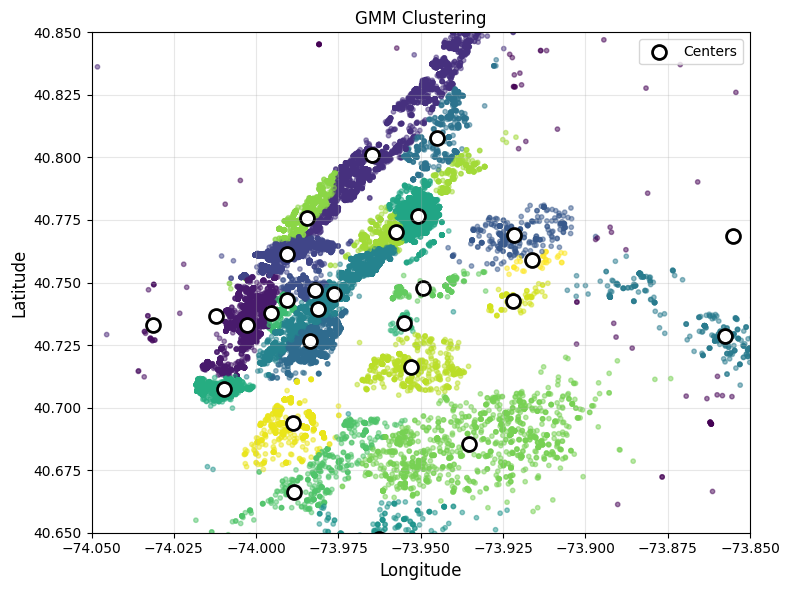

In [ ]:
# vizualization of gm (train)
my_gm.fit(X_train_ll)
#my_gm_train_pred = my_gm.predict(X_train_ll)
my_gm_train_probs = my_gm.ap_probs_
my_gm_train_means = my_gm.means_
#my_gm.train_cov = my_gm.covariances_
train_pred = np.argmax(my_gm_train_probs, axis=1)

plot_gmm(X_train_ll, train_pred, my_gm_train_means, title="GMM Clustering")

In [ ]:
X_train, X_test, Y_train, Y_test = preprocess_data_lasso(my_gm_train_pred, my_gm_test_pred)
#display(X_train.head())
#display(X_test.head())

In [ ]:
my_gm_coef_df, my_gm_r2_df = calc_feat_importance(pipe, X_train, X_train, Y_train, X_test, Y_test,
                                         r2_lasso_results_list,
                                         model_name="lasso_my_gm")
display(my_gm_coef_df)

,feature,coef,abs_coef
0,bathrooms,14423.057619,14423.057619
1,bedrooms,3849.760699,3849.760699
4,interest_level,-851.436842,851.436842
9,Doorman,542.372975,542.372975
15,LaundryinUnit,438.854609,438.854609
25,cluster_label,-324.812895,324.812895
13,FitnessCenter,227.652176,227.652176
5,Elevator,205.325026,205.325026
19,HighSpeedInternet,-188.248664,188.248664
12,LaundryinBuilding,-186.139734,186.139734


In [ ]:
display(my_gm_r2_df)

,model,train_r2,test_r2
0,lasso_base,0.601729,0.615800
1,lasso_my_kmeans,0.605387,0.619687
2,lasso_sk_kmeans,0.601813,0.615850
3,lasso_my_dbscan,0.605449,0.607750
4,lasso_sk_dbscan,0.605449,0.607750
5,lasso_sk_agcl,0.607272,0.620427
6,lasso_my_gm,0.604754,0.616503


In [ ]:
from sklearn.mixture import GaussianMixture
# my_gm = My_GaussianMixture(n_components=30, max_iter=100, n_init=1, init_params="random_from_data", random_state=21)
sk_gm = GaussianMixture(n_components=30, covariance_type="full", max_iter=100, n_init=1, init_params="random_from_data", random_state=21)

In [ ]:
X_train_ll, X_test_ll, Y_train, Y_test = preprocess_data_ll()
sk_gm.fit(X_train_ll)

sk_gm_train_probs = sk_gm.predict_proba(X_train_ll)
sk_gm_train_means = sk_gm.means_
sk_gm_train_pred =  np.argmax(sk_gm_train_probs, axis=1)

#sk_gm.fit(X_test_ll)
sk_gm_test_probs  = sk_gm.predict_proba(X_test_ll)
sk_gm_test_means = sk_gm.means_
sk_gm_test_pred = np.argmax(sk_gm_test_probs, axis=1)

In [ ]:
calc_sil_train_test("Sk_gm", X_train_ll, X_test_ll, sk_gm_train_pred, sk_gm_test_pred, sil_results_list)

,Model,Sil_score
0,My_KMeans - train,0.453716
1,My_KMeans - test,0.453186
2,My_KMeans - train,0.449124
3,My_KMeans - test,0.454895
4,My_DBSCAN - train,-0.112752
5,My_DBSCAN - test,-0.006866
6,My_DBSCAN - train,-0.112752
7,My_DBSCAN - test,-0.006866
8,Sk_Agg_Cl - train,0.434214
9,Sk_Agg_Cl - test,0.431026


In [ ]:
calc_time("Sk_GM", sk_gm, X_train_ll, time_results_list, data_type="train")

,model,time,data_type
0,My_KMeans,0.855550,train
1,Sk_KMeans,0.112720,train
2,My_DBSCAN,7.458416,train
3,Sk_DBSCAN,0.332626,train
4,Sk_Agg_Cl,5.011408,train(10000 samples)
5,My_GM,33.664170,train
6,Sk_GM,9.223363,train


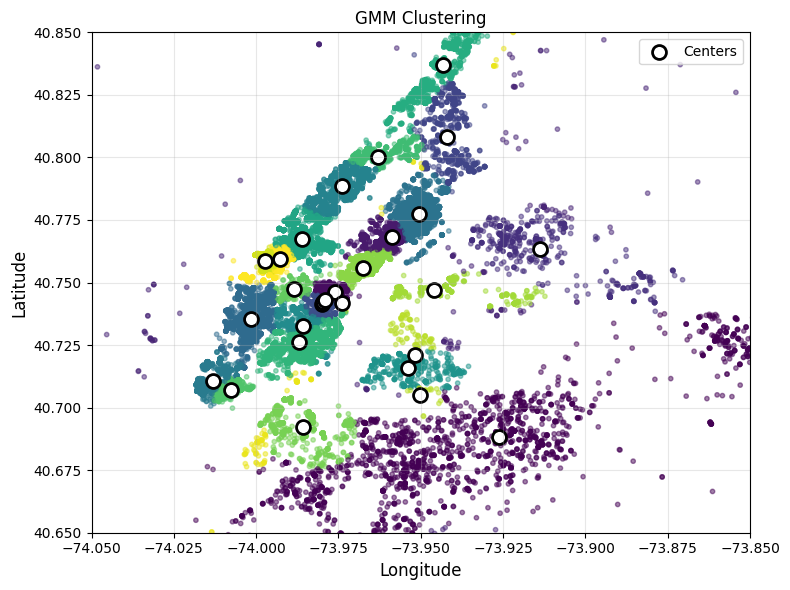

In [ ]:
# vizualization of gm (train)
sk_gm.fit(X_train_ll)
sk_gm_train_pred = sk_gm.predict(X_train_ll)
sk_gm_train_means = sk_gm.means_
sk_train_pred = np.argmax(sk_gm_train_probs, axis=1)

plot_gmm(X_train_ll, sk_train_pred, sk_gm_train_means, title="GMM Clustering")

In [ ]:
X_train, X_test, Y_train, Y_test = preprocess_data_lasso(sk_gm_train_pred, sk_gm_test_pred)
sk_gm_coef_df, sk_gm_r2_df = calc_feat_importance(pipe, X_train, X_train, Y_train, X_test, Y_test,
                                         r2_lasso_results_list,
                                         model_name="lasso_sk_gm")
display(sk_gm_coef_df)

,feature,coef,abs_coef
0,bathrooms,14400.474996,14400.474996
1,bedrooms,3883.215317,3883.215317
4,interest_level,-840.682636,840.682636
9,Doorman,540.774742,540.774742
15,LaundryinUnit,430.770605,430.770605
5,Elevator,208.725470,208.725470
25,cluster_label,207.042923,207.042923
13,FitnessCenter,197.737704,197.737704
19,HighSpeedInternet,-195.973881,195.973881
12,LaundryinBuilding,-176.368166,176.368166


In [ ]:
display(my_gm_coef_df)

,feature,coef,abs_coef
0,bathrooms,14423.057619,14423.057619
1,bedrooms,3849.760699,3849.760699
4,interest_level,-851.436842,851.436842
9,Doorman,542.372975,542.372975
15,LaundryinUnit,438.854609,438.854609
25,cluster_label,-324.812895,324.812895
13,FitnessCenter,227.652176,227.652176
5,Elevator,205.325026,205.325026
19,HighSpeedInternet,-188.248664,188.248664
12,LaundryinBuilding,-186.139734,186.139734


- Признак кластеризации по ГМ (30 компонент) входит в топ-5 фич, как в моей реализации, так и в sklearn.

# 7. Try all these algorithms with different sets of features that might be more efficient in clustering.
## In the checklist will cluster for 3 features — bedrooms, bathrooms and interest_level.

In [ ]:
def preprocess_3feat_clustering():
  train_data = pd.read_csv("train.csv")
  train_df = train_data[["bathrooms", "bedrooms", "interest_level", "price"]]
  X_train, X_test, Y_train, Y_test = train_test_split(train_df.drop("price", axis=1),
                                                     train_df["price"],
                                                     test_size=0.2,
                                                     random_state=21)
  return X_train, X_test, Y_train, Y_test

In [ ]:
X_train_3f, X_test_3f, Y_train_3f, Y_test_3f = preprocess_3feat_clustering()

In [ ]:
# KMeans
sk_kmeans = KMeans(n_clusters=30, init="k-means++", random_state=21, max_iter=100)
sk_kmeans.fit(X_train_3f)

sk_kmeans_train_pred = sk_kmeans.predict(X_train_3f)
sk_kmeans_test_pred = sk_kmeans.predict(X_test_3f)

X_train, X_test, Y_train, Y_test = preprocess_data_lasso(sk_kmeans_train_pred, sk_kmeans_test_pred)
sk_kmeans_coef_df, sk_kmeans_r2_df = calc_feat_importance(pipe, X_train, X_train, Y_train, X_test, Y_test,
                                         r2_lasso_results_list,
                                         model_name="lasso_sk_kmeans_3f")
display(sk_kmeans_coef_df.head(15))

,feature,coef,abs_coef
0,bathrooms,12863.169448,12863.169448
1,bedrooms,3577.181541,3577.181541
4,interest_level,-1173.732129,1173.732129
25,cluster_label,971.478241,971.478241
9,Doorman,551.644083,551.644083
15,LaundryinUnit,426.102025,426.102025
13,FitnessCenter,197.679005,197.679005
5,Elevator,196.947471,196.947471
12,LaundryinBuilding,-178.244425,178.244425
19,HighSpeedInternet,-174.708939,174.708939


- cluster_label - 13й по важности признак.

In [ ]:
# DBSCAN
sk_dbscan = DBSCAN(eps=0.001, min_samples=5, metric="euclidean", leaf_size=40, algorithm="kd_tree", n_jobs=-1)
#sk_dbscan.fit(X_train_3f)

sk_dbscan_train_pred = sk_dbscan.fit_predict(X_train_3f)
sk_dbscan_test_pred = sk_dbscan.fit_predict(X_test_3f)

X_train, X_test, Y_train, Y_test = preprocess_data_lasso(sk_dbscan_train_pred, sk_dbscan_test_pred)
sk_dbscan_coef_df, sk_dbscan_r2_df = calc_feat_importance(pipe, X_train, X_train, Y_train, X_test, Y_test,
                                         r2_lasso_results_list,
                                         model_name="lasso_sk_dbscan_3f")
display(sk_dbscan_coef_df.head(8))

,feature,coef,abs_coef
0,bathrooms,13728.318267,13728.318267
1,bedrooms,3893.060884,3893.060884
4,interest_level,-916.121053,916.121053
9,Doorman,551.504918,551.504918
25,cluster_label,442.417293,442.417293
15,LaundryinUnit,438.838258,438.838258
13,FitnessCenter,211.284725,211.284725
5,Elevator,208.979840,208.979840


- cluster_label - 6й по важности признак.

In [ ]:
# AGNES - 10000 samples

sk_agcl = AgglomerativeClustering(n_clusters=5, metric='euclidean', linkage='ward')
#sk_agcl.fit(X_train_3f)

sk_agcl_train_pred = sk_agcl.fit_predict(X_train_3f[:10000])
sk_agcl_test_pred = sk_agcl.fit_predict(X_test_3f)

train_df = pd.read_csv('train.csv')
X_train, X_test, Y_train, Y_test = train_test_split(train_df.drop("price", axis=1),
                                                     train_df["price"],
                                                     test_size=0.2,
                                                     random_state=21)
X_train = X_train[:10000]
Y_train = Y_train[:10000]
X_train["cluster_label"] = sk_agcl_train_pred
X_test["cluster_label"] = sk_agcl_test_pred
#display(X_train.head())
#display(X_test.head())


sk_agcl_coef_df, sk_agcl_r2_df = calc_feat_importance(pipe, X_train, X_train, Y_train, X_test, Y_test,
                                         r2_lasso_results_list,
                                         model_name="lasso_sk_agcl_3f")
display(sk_agcl_coef_df.head(8))

,feature,coef,abs_coef
0,bathrooms,5881.940824,5881.940824
1,bedrooms,4069.908222,4069.908222
9,Doorman,525.340054,525.340054
4,interest_level,-498.278680,498.278680
15,LaundryinUnit,435.280917,435.280917
25,cluster_label,-349.136738,349.136738
10,Dishwasher,197.543925,197.543925
5,Elevator,196.627707,196.627707


- cluster_label - 6й по важности признак.

In [ ]:
# Gaussian Mixture
sk_gm = GaussianMixture(n_components=5, covariance_type="full", max_iter=100, n_init=1, init_params="random_from_data", random_state=21)
sk_gm_train_pred = sk_gm.fit_predict(X_train_3f)
sk_gm_test_pred = sk_gm.fit_predict(X_test_3f)

X_train, X_test, Y_train, Y_test = preprocess_data_lasso(sk_gm_train_pred, sk_gm_test_pred)
sk_gm_coef_df, sk_gm_r2_df = calc_feat_importance(pipe, X_train, X_train, Y_train, X_test, Y_test,
                                         r2_lasso_results_list,
                                         model_name="lasso_sk_gm_3f")
display(sk_gm_coef_df.head(8))

,feature,coef,abs_coef
0,bathrooms,13702.503825,13702.503825
1,bedrooms,3855.047024,3855.047024
4,interest_level,-605.135594,605.135594
9,Doorman,551.564755,551.564755
25,cluster_label,466.227667,466.227667
15,LaundryinUnit,435.609654,435.609654
5,Elevator,209.278846,209.278846
13,FitnessCenter,206.064578,206.064578


- cluster_label - 5й по важности признак.

# 8. Compare the results with the complexity, speed and accuracy of these methods.

## Сложность и скорость алгоритмов

In [ ]:
time_df = pd.DataFrame(time_results_list)
display(time_df)

,model,time,data_type
0,My_KMeans,0.855550,train
1,Sk_KMeans,0.112720,train
2,My_DBSCAN,7.458416,train
3,Sk_DBSCAN,0.332626,train
4,Sk_Agg_Cl,5.011408,train(10000 samples)
5,My_GM,33.664170,train
6,Sk_GM,9.223363,train


- n - n_samples
- c - num_clusters
- i - iterations
- f - n_features

- KMeans:

O( i * n * c * f )

1) Назначение кластера - вычисление расстояния для каждой точки данных до каждого из центроидов - O(n_samples * n_clusters * n_features)
2) Пересчет центроидов - вычисление среднего по всем измерениям для каждого из кластеров (n_samples * n_features)

По кол-ву данных (n_samples) скорость линейна, поэтому алгоритм достаточно быстрый (что видно из таблички выше), однако чувствителен к начальному выбору центроидов (может сходиться к локальному минимуму), поэтому часто запускают несколько раз, а также используют улучшенную инициализацию kmeans++.

- DBSCAN:

O( n * n * f ) - наивная реализация, когда для каждой точки ищутся все соседи в радиусе eps.

O(n * logn) - реализация с использованием многомерных бинарных деревьев поиска (KD-tree, Ball-tree). С его помощью запрос на поиск всех соседей выполняется за лог время (каждый раз спускаемся только в одну из ветвей дерева). Однако при высоком кол-ве признаков (проклятие размерности) поиск в таком дереве может снова приближаться к O(n), поэтому итоговая сложность во многом определяется параметрами eps, min_samples.

Оригинальная реализация поддерживает как наивный алгоритм, так и с использованием деревьев (параметр algorithm). В таблице время для запуска с использованием kd-tree.

- AGNES:

O( n * n * n) - наивный алгоритм (на каждом шаге вычисляется попарное расстояние между кластерами)

O(n * n * logn) или O(n * n * f) - оптимизированные варианты с использованием, например, предвычисленной матрицы расстояний и улучшенных метода поиска (поиск минимума в матрице через min_heap).

Основной ограничивающий фактор даже с оптимизациями - память: чтобы хранить матрицу расстояний размером n*n.


- GMM:

O( i * n * c * f * f )

На Е-шаге алгоритма для каждой точки из каждого кластера вычисляется вероятность принадлежности - вычисление значения многомерного гауссова распредления через матрицу ковариации размером n_feat * n_feat.
Если коварационные матрицы диагональные, сложность снижается до n_feat.

В целом из-за операций с ковариационными матрицами алгоритм тяжелее KMeans, но легче агломеративного кластеринга.

## Общий вывод:
1) Лидер по скорости - KMeans. Линейно зависит от числа сэмплов в данных, предпочтителен для работы с большими данными и выскопроизводителен; подходит для работы со сферическими кластерами.
2) DBSCAN следующий по скорости, быстрый для данных средних размеров при использовании бинарных деревьев поиска. В очень высокой размерности становится бесполезен; преимущество - находить кластеры необычной формы.
3) GMM - медленный, специфический для задач инструмент кластеризации (когда важна вероятностная модель - мягкие веротяности, а не жесткая принадлежность к классу- или кластеры эллиптической формы). Плохо масштабируется из-за работы с матрицами.
4) AGNES - самый слоу, кубическая/квадратичная сложность по времени и памяти, применим только для небольших датасетов. Его сила в специфике - когда нужна дендрограмма и неясны предположения о форме кластеров (использует меру близости, а не геометрию данных).

## Точность предсказаний (кластеризация)

### Silhoette-score

In [ ]:
# silhoette score - чем ближе к 1, тем лучше  [-1;1]
sil_df = pd.DataFrame(sil_results_list)
display(sil_df)

,Model,Sil_score
0,My_KMeans - train,0.453716
1,My_KMeans - test,0.453186
2,My_KMeans - train,0.449124
3,My_KMeans - test,0.454895
4,My_DBSCAN - train,-0.112752
5,My_DBSCAN - test,-0.006866
6,My_DBSCAN - train,-0.112752
7,My_DBSCAN - test,-0.006866
8,Sk_Agg_Cl - train,0.434214
9,Sk_Agg_Cl - test,0.431026


- Silhoette-score как метрика предполагает, что хороший кластер - компактный и хорошо отделенный от других.



$$s = \frac{b - a}{\max(a, b)}$$

- где:

- $a$ — среднее расстояние от данной точки до всех других точек в том же кластере (мера внутрикластерной плотности).
- $b$ — среднее расстояние от данной точки до всех других точек в ближайшем соседнем кластере (мера межкластерного разделения).
Общий Silhouette Score для всего набора данных — это среднее значение $s$ для всех точек.

- Поэтому он наиболее информативен для KMeans, GMM и AGNES. Видно, что для всех этих моделей и на тренировочной, и на тестовой выборках он находится в районе 0.4, что считается показателем слабой структуры кластеризации - то есть либо кластеры плохо разделены, либо имеют сложную форму.

- Для алгоритмов, которые создают цепочки и вытянутые кластеры, данная метрика неинформативна (DBSCAN, AGNES с критерием связи single).

### DBI

In [ ]:
# davies_bouldin_score - чем меньше, тем лучше
dbs_df = pd.DataFrame(dbs_results_list)
display(dbs_df)

,Model,Davies-Bouldin_score
0,My_KMeans - train,0.519777
1,My_KMeans - test,0.639123
2,My_KMeans - train,0.505640
3,My_KMeans - test,0.664326
4,My_DBSCAN - train,2.798234
5,My_DBSCAN - test,1.805944
6,My_DBSCAN - train,2.798234
7,My_DBSCAN - test,1.805944
8,Sk_Agg_Cl - train,0.495873
9,Sk_Agg_Cl - test,0.622633


- Индекс Девиса-Болдуина оценивает кач-во кластеризации по соотношению внутрикластерного и межкластерного расстояний:

 $$DBI = \frac{1}{N} \sum_{i=1}^{N} \max_{j \neq i} \left( \frac{\sigma_i + \sigma_j}{d(c_i, c_j)} \right)$$

- где:

- $N$ — количество кластеров.
- $\sigma_i$ — среднее расстояние между каждой точкой в кластере - $i$ и центроидом кластера $i$$i$ (мера рассеяния внутри кластера).
- $d(c_i, c_j)$ — расстояние между центроидами кластеров $i$ и $j$ (мера разделения между кластерами).


- Цель DBI — минимизировать это значение, так как меньшее значение указывает на лучшую кластеризацию с компактными и хорошо разделенными кластерами.

- В целом метрика универсальная, может быть менее информативна в случае DBSCAN, потому что из формулы видно, что все-таки работает в парадигме центроидной кластеризации.

- Значения меньше 1 считаются хорошими (в моем случае это алгоритмы KMeans, AGNES).

- Для GMM получились значения около 2-3 (как в случае моей реализации, так и оригинальной) - это указывает на проблемы с компактностью и разделимостью найденных кластеров.

### Distortion

In [ ]:
dist_results_list

[{'model': 'My_KMeans', 'distortion': '5.0256'},
 {'model': 'Sk_KMeans', 'distortion': '4.9946'}]

In [ ]:
# distortion/inertia - среднеквадратичное расстояние до центра кластера; специфичное для kmeans
# чем меньше, тем лучше
dist_df = pd.DataFrame(dist_results_list)
display(dist_df)

,model,distortion
0,My_KMeans,5.0256
1,Sk_KMeans,4.9946


- Дисторсия для моей реализации и оригинальной близка. Сама по себе эта метрика мало говорит о качестве кластеризации (по сути 0 она будет равна только в случае каждая точка=отдельный кластер), однако зависимость дисторсии от кол-ва кластеров позволяет найти их оптимальное число по методу локтя.

## Точность предсказаний (лин регрессия на основе фич с добавлением cluster_label)

In [ ]:
r2_df = pd.DataFrame(r2_lasso_results_list)
display(r2_df)

,model,train_r2,test_r2
0,lasso_base,0.601729,0.615800
1,lasso_my_kmeans,0.605387,0.619687
2,lasso_sk_kmeans,0.601813,0.615850
3,lasso_my_dbscan,0.605449,0.607750
4,lasso_sk_dbscan,0.605449,0.607750
5,lasso_sk_agcl,0.607272,0.620427
6,lasso_my_gm,0.604754,0.616503
7,lasso_sk_gm,0.603127,0.618474
8,lasso_sk_kmeans_3f,0.608678,0.621342
9,lasso_sk_dbscan_3f,0.602929,0.614146


- Для всех моделей коэфф детерминации колеблется около 0.6, то есть построенные регрессионные модели объясняют около 60% дисперсии таргета.
- При добавлении метки кластера как признака данная метрика улучшилась на 0.1-0.2, что указывает на то, что признак вносит положительный вклад в предсказание модели.

## Отбор признаков по Лассо
- посчитал новый признак - номер кластера - информативным практически для всех рассмотренных алгоритмов кластеризации (как в случае кластеризации по географическим координатам, так и в случае группировки по сочетанию спальни-ванны-уровень интереса.)

# 9*. Bonus
## 1. For additional task, you can try different models instead of Lasso.
## 2. You could apply optimization methods to hyperparameters of algorithms, e.g. to find the optimal number of clusters.
## 3. You could combine cluster features from different algorithms and apply feature selection from previous chapters.

In [ ]:
# берем признаки-удобства
train_df = pd.read_csv('train.csv')
train_df = train_df[["Doorman", "LaundryinUnit", "Elevator", "FitnessCenter", "price"]]
X_train, X_test,Y_train, Y_test = train_test_split(train_df.drop("price", axis=1),
                                                     train_df["price"],
                                                     test_size=0.2,
                                                     random_state=21)

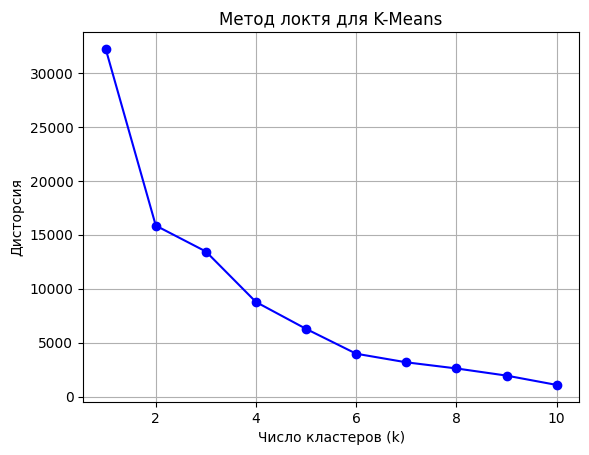

In [ ]:
# находим оптим кол-во параметров для кминс по методу локтя
k_range = range(1, 11)
inertias = []

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=21,init="k-means++")
    kmeans.fit(X_train)
    inertias.append(kmeans.inertia_)

plt.plot(k_range, inertias, 'bo-')
plt.xlabel('Число кластеров (k)')
plt.ylabel('Дисторсия')
plt.title('Метод локтя для K-Means')
plt.grid(True)
plt.show()

In [ ]:
# 6 кластеров ок
optimal_k = 6
kmeans_optimal = KMeans(n_clusters=optimal_k, random_state=21,init="k-means++")
X_train['facilities_kmeans_cluster'] = kmeans_optimal.fit_predict(X_train)

dbscan = DBSCAN(eps=0.5, min_samples=5)
X_train['facilities_dbscan_cluster'] = dbscan.fit_predict(X_train)

In [ ]:
# попробуем ридж и бустинг
from sklearn.linear_model import Ridge
from sklearn.ensemble import GradientBoostingRegressor

models = {
    'Ridge': Ridge(alpha=1.0),
    'GradientBoosting': GradientBoostingRegressor(n_estimators=100, random_state=21)
}


for name, model in models.items():
    if name == 'Ridge':
        mm = MinMaxScaler()
        X_train_scaled = mm.fit_transform(X_train)
        model.fit(X_train_scaled, Y_train)
        df = pd.DataFrame({
            'feature': X_train.columns,
            'coef': model.coef_,
            'abs_coef': np.abs(model.coef_)
        }).sort_values('abs_coef', ascending=False)
    else:
        model.fit(X_train, Y_train)
        df = pd.DataFrame({
            'feature': X_train.columns,
            'importance': model.feature_importances_
        }).sort_values('importance', ascending=False)

    display(df.head(6))
    print("\n\n")

,feature,coef,abs_coef
1,LaundryinUnit,657.295486,657.295486
0,Doorman,594.679140,594.679140
5,facilities_dbscan_cluster,474.209964,474.209964
2,Elevator,244.006401,244.006401
3,FitnessCenter,182.872541,182.872541
4,facilities_kmeans_cluster,-164.932190,164.932190


,feature,importance
0,Doorman,0.558784
5,facilities_dbscan_cluster,0.357006
1,LaundryinUnit,0.044093
2,Elevator,0.025746
3,FitnessCenter,0.007449
4,facilities_kmeans_cluster,0.006921


In [ ]:
train_df = pd.read_csv('train.csv')
X_train, X_test, Y_train, Y_test = train_test_split(train_df.drop("price", axis=1),
                                                     train_df["price"],
                                                     test_size=0.2,
                                                     random_state=21)

X_train['facilities_kmeans_cluster'] = kmeans_optimal.fit_predict(X_train)
X_train['facilities_dbscan_cluster'] = dbscan.fit_predict(X_train)

X_test['facilities_kmeans_cluster'] = kmeans_optimal.predict(X_test)
X_test['facilities_dbscan_cluster'] = dbscan.fit_predict(X_test)

cluster_cols = ['facilities_kmeans_cluster', 'facilities_dbscan_cluster']
other_cols = [col for col in X_train.columns if col not in cluster_cols]

scaler =  MinMaxScaler()
X_train_other_scaled = scaler.fit_transform(X_train[other_cols])
X_test_other_scaled = scaler.transform(X_test[other_cols])

X_train_ridge = np.hstack([X_train_other_scaled, X_train[cluster_cols].values])
X_test_ridge = np.hstack([X_test_other_scaled, X_test[cluster_cols].values])

X_train_gb = X_train_ridge.copy()
X_test_gb = X_test_ridge.copy()

ridge = Ridge(alpha=1.0)
gb = GradientBoostingRegressor(n_estimators=100, random_state=21)

ridge.fit(X_train_ridge, Y_train)
gb.fit(X_train_gb, Y_train)

GradientBoostingRegressor(random_state=21)

In [ ]:
Y_pred_ridge = ridge.predict(X_test_ridge)
Y_pred_gb = gb.predict(X_test_gb)

In [ ]:
from sklearn.metrics import r2_score

r2_ridge = r2_score(Y_test, Y_pred_ridge)
r2_gb = r2_score(Y_test, Y_pred_gb)

print(r2_ridge)
print(r2_gb)

0.6167215170210856
0.7743828347997647


In [ ]:
# без фичи лейбла кластера
train_df = pd.read_csv('train.csv')
X_train, X_test, Y_train, Y_test = train_test_split(train_df.drop("price", axis=1),
                                                     train_df["price"],
                                                     test_size=0.2,
                                                     random_state=21)

cluster_cols = ['facilities_kmeans_cluster', 'facilities_dbscan_cluster']
other_cols = [col for col in X_train.columns if col not in cluster_cols]

X_train_ridge = scaler.fit_transform(X_train[other_cols])
X_test_ridge = scaler.transform(X_test[other_cols])

X_train_gb = X_train_ridge.copy()
X_test_gb = X_test_ridge.copy()

ridge = Ridge(alpha=1.0)
gb = GradientBoostingRegressor(n_estimators=100, random_state=21)

ridge.fit(X_train_ridge, Y_train)
gb.fit(X_train_gb, Y_train)

Y_pred_ridge = ridge.predict(X_test_ridge)
Y_pred_gb = gb.predict(X_test_gb)


r2_ridge = r2_score(Y_test, Y_pred_ridge)
r2_gb = r2_score(Y_test, Y_pred_gb)

print(r2_ridge)
print(r2_gb)

0.6165470070365159
0.7734665278133335


- В случае градиентного бустинга получилось незначительное улучшение метрики r2 на тесте при добавлении метки кластера facilities_dbscan_cluster.